### Der Transfertensors

Gegeben sei ein Anfangszustand $\rho_0$. Die Zeitentwicklung zu einem beliebigen Schritt $n$ wird durch eine Familie von dynamischen Karten (Superoperatoren) $\mathcal{E}_n$ beschrieben (das ist bei uns `maps`), sodass:$$\rho_n = \mathcal{E}_n \rho_0$$

Bei `maps` für HEOM sieht man ganz gut dass man $\rho_S(n\cdot \Delta t)$ bekommt wenn man den $n$-ten Eintrag von `maps` nimmt und ihn mit einem initial state multipliziert. Wenn das System Markovsch (gedächtnislos) wäre, bräuchte man nur den Zustand vom vorherigen Schritt, um den nächsten zu berechnen: $\rho_n = \mathcal{E}_1 \rho_{n-1}$.Da wir uns im nicht-Markovschen Regime befinden, hängt der aktuelle Zustand von der gesamten Vergangenheit ab. Wir suchen also eine diskrete Faltungsgleichung der Form:$$\rho_n = \sum_{m=1}^n T_m \rho_{n-m}$$Hier ist $T_m$ der Transfer-Tensor. Er quantifiziert exakt: "Wie stark beeinflusst der Zustand, der vor $m$ Zeitschritten herrschte, unseren aktuellen Zustand?" Wir können sagen dass $\rho_n$ eine Linearkombination von alten Zuständen ist, sowohl die unitäre Entwicklung $\rho_S(t) = \text{Tr}_B [ U(t) (\rho_S(0) \otimes \rho_B(0)) U^\dagger(t) ]$ als auch die Spur linear sind: Wenn du den Anfangszustand des Systems verdoppelst, verdoppelt sich auch $\rho_{S}(t)$. Man kann das elegant mit dem Nakajima-Zwanzig-Formalismus zeigen.

Um die Tensoren $T_m$ zu berechnen, setzen wir die Definition der dynamischen Karte ($\rho_k = \mathcal{E}_k \rho_0$) in unsere Faltungsgleichung ein:$$\mathcal{E}_n \rho_0 = \sum_{m=1}^n T_m \mathcal{E}_{n-m} \rho_0$$Da diese Gleichung für jeden beliebigen Anfangszustand $\rho_0$ gelten muss, können wir $\rho_0$ weglassen und erhalten eine Operatorgleichung:$$\mathcal{E}_n = \sum_{m=1}^n T_m \mathcal{E}_{n-m}$$Um nun den Tensor $T_n$ für den aktuellen Schritt zu isolieren, spalten wir den letzten Term (für $m=n$) von der Summe ab. Wir wissen, dass $\mathcal{E}_0 = \mathbb{I}$ (der nullte Schritt verändert das System nicht). Also ist der Term für $m=n$ einfach $T_n \mathcal{E}_0 = T_n$. Umgestellt nach $T_n$ ergibt das:$$T_n = \mathcal{E}_n - \sum_{m=1}^{n-1} T_m \mathcal{E}_{n-m}$$Hiermit wird aus der exakten Gesamtdynamik iterativ der reine Kurzzeit- und Gedächtnisanteil herausgefiltert. In der Praxis schneidet man diese Reihe nach $K$ Schritten ab, da das Bad irgendwann "vergisst" ($T_{m > K} \approx 0$).

Da $\mathcal{E}_n \equiv \mathcal{E}(n\Delta t)$ und somit $\mathcal{E}_0=1$ (Propagieren um 0 Zeitschritte macht nichts) folgt $\mathcal{E}_1 = \sum_{m=1}^1 T_m \mathcal{E}_{1-m} = T_1 \mathcal{E}_0 = T_1$. Daraus folgt wiederum:
$$T_2 = \mathcal{E}_2 - \sum_{m=1}^{2-1} T_m \mathcal{E}_{2-m} = \mathcal{E}_2 - T_1 \mathcal{E}_{1} = \mathcal{E}_2 - \mathcal{E}_{1} \mathcal{E}_{1}$$
$$T_3 = \mathcal{E}_3 - \sum_{m=1}^{2} T_m \mathcal{E}_{3-m} = \mathcal{E}_3 - \left( T_1 \mathcal{E}_2 + T_2 \mathcal{E}_1 \right) = \mathcal{E}_3 - \mathcal{E}_1 \mathcal{E}_2 - \left( \mathcal{E}_2 - \mathcal{E}_1 \mathcal{E}_1 \right) \mathcal{E}_1 = \mathcal{E}_3 - \mathcal{E}_1 \mathcal{E}_2 - \mathcal{E}_2 \mathcal{E}_1 + \mathcal{E}_1 \mathcal{E}_1 \mathcal{E}_1$$

$$\begin{aligned} T_4 &= \mathcal{E}_4 - \sum_{m=1}^{3} T_m \mathcal{E}_{4-m} = \mathcal{E}_4 - \left( T_1 \mathcal{E}_3 + T_2 \mathcal{E}_2 + T_3 \mathcal{E}_1 \right) \\ &= \mathcal{E}_4 - \mathcal{E}_1 \mathcal{E}_3 - \left( \mathcal{E}_2 - \mathcal{E}_1 \mathcal{E}_1 \right) \mathcal{E}_2 - \left( \mathcal{E}_3 - \mathcal{E}_1 \mathcal{E}_2 - \mathcal{E}_2 \mathcal{E}_1 + \mathcal{E}_1 \mathcal{E}_1 \mathcal{E}_1 \right) \mathcal{E}_1 \\ &= \mathcal{E}_4 - \mathcal{E}_1 \mathcal{E}_3 - \mathcal{E}_2 \mathcal{E}_2 + \mathcal{E}_1 \mathcal{E}_1 \mathcal{E}_2 - \mathcal{E}_3 \mathcal{E}_1 + \mathcal{E}_1 \mathcal{E}_2 \mathcal{E}_1 + \mathcal{E}_2 \mathcal{E}_1 \mathcal{E}_1 - \mathcal{E}_1 \mathcal{E}_1 \mathcal{E}_1 \mathcal{E}_1 \end{aligned}$$

### Der Companionpropagator
Die Transfer-Tensor-Gleichung, die wir gerade hergeleitet haben, benötigt aber exakt diese Historie:$$\rho_n = T_1 \rho_{n-1} + T_2 \rho_{n-2} + \dots + T_K \rho_{n-K}$$Um das auf einem Quantencomputer (oder Simulator) laufen zu lassen, nutzt die Funktion companion_propagator einen eleganten Trick der linearen Algebra: Sie wandelt die Rekursionsgleichung $K$-ter Ordnung in eine Gleichung 1. Ordnung um, indem sie den Zustandsraum künstlich vergrößert.

Anstatt nur die aktuelle Dichtematrix $\rho$ zu betrachten, definieren wir einen großen Blockvektor $X$, der ein "gleitendes Fenster" (sliding window) der letzten $K$ Zustände enthält. Wenn wir uns im Schritt $n-1$ befinden, sieht unser Input-Register so aus:$$X_{n-1} = \begin{pmatrix} \rho_{n-1} \\ \rho_{n-2} \\ \rho_{n-3} \\ \vdots \\ \rho_{n-K} \end{pmatrix}$$Unser Ziel ist es, einen einzigen Operator $E$ zu finden, der diesen Vektor einen Zeitschritt in die Zukunft propagiert: $X_n = E X_{n-1}$.

Der Operator $E$ muss zwei Aufgaben gleichzeitig erfüllen:
- Den neuen Zustand $\rho_n$ berechnen und in die oberste Position schreiben.
- Alle alten Zustände um eine Position nach unten verschieben (wobei der älteste Zustand $\rho_{n-K}$ aus dem Register "herausfällt").

Dies geschieht durch eine sogenannte Block-Begleitmatrix (Companion Matrix). Sie hat folgende Struktur:$$E = \begin{pmatrix}  T_1 & T_2 & T_3 & \dots & T_K \\  \mathbb{I} & 0 & 0 & \dots & 0 \\  0 & \mathbb{I} & 0 & \dots & 0 \\  \vdots & \vdots & \ddots & \ddots & \vdots \\  0 & 0 & \dots & \mathbb{I} & 0  \end{pmatrix}$$

Wenn du nun das Matrix-Vektor-Produkt $E X_{n-1}$ im Kopf ausführst, siehst du, was passiert:
- Die erste Zeile multipliziert sich mit dem Vektor zu: $T_1 \rho_{n-1} + T_2 \rho_{n-2} + \dots + T_K \rho_{n-K}$. Das ist genau unser gesuchtes $\rho_n$.
- Die zweite Zeile besteht nur aus einer Identitätsmatrix $\mathbb{I}$ an der ersten Position. Sie greift sich also einfach $\rho_{n-1}$ und schiebt es in die zweite Zeile des neuen Vektors.
- Die dritte Zeile greift sich $\rho_{n-2}$ und so weiter.

Die Funktion `companion_propagator` baut exakt diese Matrix $E$ in zwei simplen For-Schleifen auf. D ist dabei die Dimension des ursprünglichen Hilbertraums (bzw. Liouville-Raums), also die Größe eines einzelnen $\rho$. Es wird über alle berechneten Transfer-Tensoren iteriert. Sie werden nebeneinander in die allerersten D Zeilen (die erste Blockzeile E[:D, ...]) der leeren Matrix eingefügt.

## 5. Route B — Sz.-Nagy dilation and the price of non-complete-positivity

### Warum Stinespring in Route B bei $E$ scheitert
Die Stinespring-Dilatation (Satz 7 und 8 in deinem Text) ist maßgeschneidert für sogenannte Quantenkanäle. Das bedeutet, sie funktioniert ausschließlich für vollständig positive und spurerhaltende Abbildungen (CPTP-Maps). Damit du Stinespring anwenden kannst, müssen zwei harte Bedingungen erfüllt sein:
- Completely Positive (CP): Die Abbildung muss eine Kraus-Zerlegung $\Phi(\rho) = \sum_k M_k \rho M_k^\dagger$ besitzen.- Trace-Preserving (TP): Die Kraus-Operatoren müssen die Isometrie-Bedingung $\sum_k M_k^\dagger M_k = \mathbb{1}$ erfüllen.

Der Companion-Operator $E$ erfüllt keine dieser Bedingungen:
- Falscher Zustandsraum: $E$ wirkt nicht auf eine normale Dichtematrix $\rho$, sondern auf einen künstlich vergrößerten Blockvektor $X$, der ein gleitendes Fenster der letzten $K$ Zustände enthält (das "Gedächtnis"). Eine Abbildung, die Blockvektoren verschiebt und mit Transfer-Tensoren $T_m$ gewichtet, ist kein physikalischer Quantenkanal im Sinne einer CP-Map. Es gibt hier keine Kraus-Operatoren $M_k$ für $E$. Damit ein Krausoperator zu einer map existiert muss sie CP sein da die Krausoperatoren aus der Wurzel der eigenwerte der zugehörigen Choimatrix bestehen.
- Die Norm-Explosion (Nicht-Isometrisch): Die Isometrie-Bedingung von Stinespring ($\sum M_k^\dagger M_k = \mathbb{1}$) garantiert, dass die Spektralnorm strikt erhalten bleibt. Wie in Proposition 14 gezeigt wird, ist die Norm von $E$ jedoch $\Vert{}E\Vert{}_2 \approx \sqrt{2} > 1$. Ein Operator, dessen Norm größer als 1 ist, kann unmöglich Teil einer isometrischen Einbettung $V^\dagger V = \mathbb{1}$ sein.

Da $E$ weder CPTP ist noch die Norm erhält, existiert schlichtweg keine Isometrie $V$, die $E$ deterministisch in einen größeren unitären Raum einbettet.

### Warum Sz.-Nagy das Problem löst
Die Sz.-Nagy-Dilatation (Theorem 12) fragt nicht nach Quantenphysik. Sie ist ein universelles Resultat der linearen Algebra, das für jede beliebige Matrix $A$ funktioniert, solange diese eine Kontraktion ist (also $\Vert{}A\Vert{}_2 = \max_{x \neq 0} \frac{\Vert{}Ax\Vert{}}{\Vert{}x\Vert{}} \le 1$).Da uns die physikalische CPTP-Struktur fehlt, weichen wir auf dieses rein mathematische Theorem aus. Das Vorgehen sieht so aus:
- Schritt 1: Normierung zur Kontraktion:
Da $\Vert{}E\Vert{}_2 \approx \sqrt{2}$ größer als 1 ist, definieren wir eine skalierte Version:$$A = \frac{E}{s} \quad \text{mit} \quad s = \Vert{}E\Vert{}_2 \cdot (1 + 10^{-12})$$Jetzt ist garantiert, dass $\Vert{}A\Vert{}_2 \le 1$ gilt. $A$ ist eine Kontraktion.

- Schritt 2: Einbettung in eine unitäre Matrix:
Weil $A$ eine Kontraktion ist, können wir die Hermiteschen, positiv semidefiniten Matrizen $B = \sqrt{\mathbb{1} - AA^\dagger}$ und $C = \sqrt{\mathbb{1} - A^\dagger A}$ berechnen (Lemma 10). Damit lässt sich $A$ als oberer linker Block in eine größere unitäre Matrix $U$ einbauen:$$U = \begin{pmatrix} A & B \\ C & -A^\dagger \end{pmatrix}$$

**Der Preis für Sz.-Nagy: Post-Selection**:
Während Stinespring eine deterministische Abbildung liefert (die Umgebung wird am Ende einfach "vergessen" bzw. herausgetraced, was mit Wahrscheinlichkeit $p=1$ funktioniert), erzwingt die mathematische Blockstruktur von Sz.-Nagy eine probabilistische Messung.Wenn wir $U$ auf unseren Zustand und ein frisches Ancilla-Qubit $\vert{}0\rangle$ anwenden, erhalten wir:$$U \begin{pmatrix} x \\ 0 \end{pmatrix} = \begin{pmatrix} A x \\ C x \end{pmatrix} = Ax \ket{0} + Cx \ket{1}$$
Damit wir unseren gewünschten Propagations-Schritt $Ax$ (also den oberen Block) erhalten, müssen wir das Ancilla-Qubit messen und zwingend das Ergebnis $\vert{}0\rangle$ erhalten. Wenn das Ancilla-Qubit als $\vert{}1\rangle$ gemessen wird (was dem unteren Block $Cx$ entspricht), ist die Simulation fehlgeschlagen und der Durchlauf muss verworfen werden.


> Theorem 12: Die Sz.-Nagy DilatationTheorem 12 (Sz.-Nagy). Wenn die Operatornorm $\Vert{}A\Vert{}_2 \le 1$ ist, dann ist die folgende Blockmatrix unitär (es gilt also $U^\dagger U = \mathbb{1}$):$$U = \begin{pmatrix} A & B \\ C & -A^\dagger \end{pmatrix}$$wobei $B = \sqrt{\mathbb{1} - AA^\dagger}$ und $C = \sqrt{\mathbb{1} - A^\dagger A}$.

### 5.3 Post-Selection and its probability

Um die nicht-unitäre Dynamik auf der Quantenhardware auszuführen, nutzen wir einen hybriden Ansatz aus Quanten-Post-Selektion und klassischer Buchhaltung. Wir präparieren zunächst ein Ancilla-Qubit im Zustand $\vert{}0\rangle$ und unser System-Register im Zustand $\vert{}X\rangle$. Dabei ist $\vert{}X\rangle$ ein künstlicher "Super-Vektor", in den wir die gesamte Dichtematrix des Systems (inklusive aller Populationen und Kohärenzen) sowie das Gedächtnis an die jüngsten $K$ Zeitschritte codiert haben. Da vektorisierte Dichtematrizen im Allgemeinen nicht die $L^2$-Norm 1 besitzen, muss dieser Vektor vor der Übergabe an den Quantencomputer klassisch normiert werden, sodass $\Vert{}X\Vert{}=1$ gilt.

In der Block-Notation lässt sich dieser kombinierte Startzustand als Vektor $(X,0)^{\mathsf T}$ schreiben. Wenden wir nun unsere unitäre Matrix $U$ an, spaltet sich der Zustand des Gesamtsystems in zwei Zweige auf:

$$U\begin{pmatrix}X\\0\end{pmatrix}=\begin{pmatrix}(A/s)\,X\\ C\,X\end{pmatrix} = (A/s)\,X \vert{}0\rangle + C\,X \vert{}1\rangle$$

Diese beiden Komponenten repräsentieren die Zweige, in denen sich das Ancilla-Qubit im Zustand $\vert{}0\rangle$ bzw. $\vert{}1\rangle$ befindet. Da $U$ unitär ist, addieren sich die Längenquadrate beider Zweige exakt zu 1:

$$\Vert{}(A/s)X\Vert{}^2+\Vert{}CX\Vert{}^2=\big\langle X,(A/s)^\dagger(A/s)X\big\rangle+\big\langle X,(\mathbb 1-(A/s)^\dagger(A/s))X\big\rangle=\Vert{}X\Vert{}^2 = 1$$

**Der Messkollaps und die automatische Normierung**

Der eigentliche "Trick" dieses Algorithmus passiert bei der Messung des Ancilla-Qubits (Post-Selection). Wir verwerfen alle Durchläufe, bei denen wir $\vert{}1\rangle$ messen, und betrachten nur die Fälle, in denen wir $\vert{}0\rangle$ erhalten. 

Nach der Bornschen Regel tritt dieses gewünschte Ergebnis $\vert{}0\rangle$ mit folgender Wahrscheinlichkeit auf (da $\Vert{}X\Vert{}=1$):

$$p=\big\Vert{}(A/s)X\big\Vert{}^2 = \frac{\Vert{}AX\Vert{}^2}{s^2} = \frac{\Vert{}AX\Vert{}^2}{\Vert{}X\Vert{}^2 s^2}\tag{5.2}$$

Bedingt auf dieses Messergebnis zwingt der quantenmechanische Kollaps das System-Register unwiderruflich in den zugehörigen Zweig $(A/s)X$. Da physikalische Quantenzustände nach einer Messung zwingend normiert sein müssen, teilt die Natur den Vektor automatisch durch seine eigene Länge. Die Skalierungskonstante $s$, die wir lediglich einführen mussten, um $U$ unitär zu machen, kürzt sich dabei elegant weg:

$$ \text{Zustand nach Kollaps} = \frac{(A/s)X}{\Vert{}(A/s)X\Vert{}} = \frac{\frac{1}{s} AX}{\frac{1}{s} \Vert{}AX\Vert{}} = \frac{AX}{\Vert{}AX\Vert{}} $$

**Klassisches Mitverfolgen der Physik**

Der Quantencomputer wendet also durch die Post-Selection exakt unsere gewünschte Matrix $A$ an und liefert uns den korrekten Richtungsvektor im Hilbertraum. Allerdings hat der Messkollaps die Information über die absolute Länge des Vektors (die unsere physikalischen Dichtematrix-Spuren enthält) "vergessen". 

Das ist jedoch kein Problem: Da wir die Konstante $s$ kennen und die Wahrscheinlichkeit $p$ über die Messstatistik der Hardware auslesen können, lässt sich die fehlende Normierung klassisch berechnen ($\Vert{}AX\Vert{} = s \cdot \sqrt{p}$). Der physikalische Skalierungsfaktor wird somit einfach auf dem klassischen Computer wie ein Sparbuch mitgeführt und im Post-Processing auf den Hardware-Zustand angewendet (§5.5).

### 5.4 Many steps

> Proposition 13. Sei $X_{t+1} := AX_t$ die Folge unserer unnormierten, theoretischen Vektoren. Wenn der Quantenschaltkreis die Sz.-Nagy-Dilatation $n$-mal hintereinander anwendet (jedes Mal mit einem neuen Ancilla-Qubit) und wir bei jedem dieser Qubits fordern, dass es als $\vert{}0\rangle$ gemessen wird (Post-Selection), dann ist die Gesamtwahrscheinlichkeit dafür:$$p_{\rm total} = \prod_{t=0}^{n-1}p_t = \frac{\Vert{}A^{n}X_0\Vert{}^{2}}{s^{2n}\Vert{}X_0\Vert{}^{2}}. \tag{5.3}$$

Beweis. Wir definieren $Y_t := X_t / \Vert{}X_t\Vert{}$ als den normierten Hardware-Quantenzustand, der in den Schritt $t$ hineingeht. Nach Gleichung (5.2) ist die Wahrscheinlichkeit für einen Erfolg in diesem einzelnen Schritt:
$$p_t = \frac{\Vert{}AY_t\Vert{}^2}{s^2} = \frac{\Vert{}AX_t\Vert{}^2}{s^2\Vert{}X_t\Vert{}^2} = \frac{\Vert{}X_{t+1}\Vert{}^2}{s^2\Vert{}X_t\Vert{}^2}.$$
Wenn wir nun all diese Wahrscheinlichkeiten miteinander multiplizieren, entsteht ein Teleskopprodukt:
$$\prod_{t=0}^{n-1}p_t = \frac{1}{s^{2n}}\prod_{t=0}^{n-1}\frac{\Vert{}X_{t+1}\Vert{}^2}{\Vert{}X_t\Vert{}^2} = \frac{1}{s^{2n}} \cdot \left( \frac{\color{red}{\cancel{\Vert{}X_1\Vert{}^2}}}{\Vert{}X_0\Vert{}^2} \cdot \frac{\color{lightblue}{\cancel{\Vert{}X_2\Vert{}^2}}}{\color{red}{\cancel{\Vert{}X_1\Vert{}^2}}} \cdot \frac{\color{green}{\cancel{\Vert{}X_3\Vert{}^2}}}{\color{lightblue}{\cancel{\Vert{}X_2\Vert{}^2}}} \cdot \dots \cdot \frac{\color{orange}{\cancel{\Vert{}X_{n-1}\Vert{}^2}}}{\color{purple}{\cancel{\Vert{}X_{n-2}\Vert{}^2}}} \cdot \frac{\Vert{}X_n\Vert{}^2}{\color{orange}{\cancel{\Vert{}X_{n-1}\Vert{}^2}}} \right) = \frac{1}{s^{2n}}\cdot\frac{\Vert{}X_n\Vert{}^2}{\Vert{}X_0\Vert{}^2},$$
und da nach Definition $X_n = A^nX_0$ gilt, ist der Beweis abgeschlossen. $\;\blacksquare$

Der Super-Vektor $X_t$ repräsentiert das theoretische, unnormierte Gedächtnis der Dichtematrizen ($X_{t+1} = A X_t$). Da $A$ eine physikalische Dynamik beschreibt (z.B. den Zerfall von Populationen oder den Verlust von Kohärenzen), ändert $A$ die Länge von Vektoren stetig. Selbst wenn wir bei $t=0$ mit $\Vert{}X_0\Vert{}=1$ starten würden, ist die Norm nach einem Schritt $\Vert{}X_1\Vert{} = \Vert{}A X_0\Vert{}$ schon nicht mehr 1. Und nach $n$ Schritten ist $\Vert{}X_n\Vert{} = \Vert{}A^n X_0\Vert{}$ definitiv weit entfernt von 1.

Ob wir die Ancilla-Qubits sofort nach ihrem jeweiligen Schritt messen oder alle gemeinsam ganz am Ende, spielt physikalisch überhaupt keine Rolle: Sobald der Zeitschritt $t$ vorbei ist, berührt kein einziges Gatter dieses spezifische Ancilla-Qubit $t$ jemals wieder. Daher vertauscht (kommutiert) diese Messung mit allem, was danach im Schaltkreis passiert, und die statistischen Resultate bleiben exakt gleich. Das ist das Prinzip der aufgeschobenen Messung (Deferred-Measurement Principle). Genau dieses Prinzip ermöglicht es, die Simulation als einen einzigen, durchgehenden Schaltkreis zu bauen, anstatt den Schaltkreis $n$-mal bedingt neu starten zu müssen.

Formel (5.3) offenbart die eigentliche Hürde der Route B. Für unseren ursprünglichen Begleitoperator (Companion Operator) gilt $\Vert{}E\Vert{}_2 = \sqrt{2}$, während sein Spektralradius $\rho(E) = 1$ ist. Für $n=76$ Zeitschritte ergibt das $s= \sqrt{2}^{2\cdot 76} = 2^{76}$ und somit:

$$p_{\rm total} = \frac{\Vert{}E^{n}X_0\Vert{}^{2}}{s^{2n}\Vert{}X_0\Vert{}^{2}} =\frac{1}{2^{76}}\cdot\frac{\Vert{}X_n\Vert{}^2}{\Vert{}X_0\Vert{}^2} \simeq \frac{\mathcal O(1)}{2^{76}} \approx 6.7 \times 10^{-24}.$$

Man bräuchte also grob $10^{23}$ Durchläufe (Shots) für auch nur ein einziges verwertbares Messergebnis.


### Analogie zwischen Route A und Route B

**Klarstellung der Notation:**
*   **$\rho$ (Dichtematrix):** Dies ist der tatsächliche, physikalische Zustand des Systems zu einem einzelnen Zeitschritt (z. B. $\rho_{n-1}$).
*   **$X$ (Super-Vektor):** Dies ist unser erweitertes mathematisches Konstrukt. Er bündelt die vektorisierten Dichtematrizen der letzten $K$ Zeitschritte in einem einzigen großen Spaltenvektor, um das "Gedächtnis" des Systems abzubilden. Ein kleines $x$ existiert in dieser Notation nicht mehr.

Hier ist die exakte Übersetzung (das "Wörterbuch") von Route A nach Route B:

1. **Zustand:** Die Dichtematrix $\rho$ eines einzelnen Schrittes wird abgelöst durch den unnormierten Super-Vektor $X$. Da es sich um Zustandsvektoren handelt, schreiben wir für den Startzustand der Umgebung nicht den Projektor $\vert{}0\rangle\langle0\vert{}_E$, sondern den reinen Vektor $\vert{}0\rangle_E$.
2. **Dynamik:** Die Abbildung $\Phi(\rho)$ wird zur einfachen Matrixmultiplikation $A X$, wobei $A$ im Wesentlichen unser Companion-Operator $E$ ist. Wir verwenden also auf dem Grid $X_n = E \cdot X_{n-1} = E \begin{pmatrix} \rho_{n-1} \\ \rho_{n-2} \\ \rho_{n-3} \\ \vdots \\ \rho_{n-K} \end{pmatrix}$.
3. **Gatter:** Die Stinespring-Matrix $U$ wird durch die Sz.-Nagy-Dilatation $U = \begin{pmatrix} A & B \\ C & -A^\dagger \end{pmatrix}$ ersetzt (welche $A/s$ im oberen linken Block enthält). Da wir Vektoren propagieren, fällt das $U^\dagger$ auf der rechten Seite weg.
4. **Der Müll-Operator:** Die partielle Spur $\operatorname{Tr}_E[\dots]$ (welche alle Umgebungszustände aufsummiert) wird durch die Post-Selection $\langle 0 \vert_E [\dots]$ ersetzt (welche den Vektor auf den $\vert{}0\rangle$-Zweig projiziert).
5. **Das Sparbuch:** Weil Sz.-Nagy die Matrix auf $A/s$ schrumpfen musste, kommt nach jedem Schritt klassisch der Skalierungsfaktor $s$ hinzu.

Die Rekursionsvorschrift für einen Schritt lautet also:
$$X_n = s \cdot \langle 0 \vert_E U \big( \vert{}0\rangle_E \otimes X_{n-1} \big)$$
*(Hinweis zur Notation: Das $\langle 0 \vert_E$ wirkt hier von links als inneres Produkt nur auf den Umgebungs-Teilraum und "frisst" das Ancilla-Qubit auf, sodass als Ergebnis wieder ein reiner System-Vektor der richtigen Dimension herauskommt).*

**Die $n$-fache Schachtelung für Route B:**
Wenn wir $X_n$ nun durch ständiges Ersetzen des Vorgängers ineinander verschachteln, erhalten wir das exakte Pendant zu der Route-A-Gleichung:
$$\begin{aligned} X_n &= A X_{n-1} \\ &= s \cdot \langle 0 \vert_E U \big( \vert{}0\rangle_E \otimes X_{n-1} \big) \\ &= s \cdot \langle 0 \vert_E U \bigg( \vert{}0\rangle_E \otimes \Big[ s \cdot \langle 0 \vert_E U \big( \vert{}0\rangle_E \otimes X_{n-2} \big) \Big] \bigg) \\ &= s \cdot \langle 0 \vert_E U \Bigg( \vert{}0\rangle_E \otimes \bigg[ s \cdot \langle 0 \vert_E U \Big( \vert{}0\rangle_E \otimes \big[ s \cdot \langle 0 \vert_E U ( \vert{}0\rangle_E \otimes X_{n-3} ) \big] \Big) \bigg] \Bigg) \\ &\;\;\vdots \\ &= \underbrace{ s \cdot \langle 0 \vert_E U \Bigg( \vert{}0\rangle_E \otimes \dots \Big[ s \cdot \langle 0 \vert_E U \big( \vert{}0\rangle_E \otimes X_0 \big) \Big] \dots \Bigg) }_{n\text{-fache Schachtelung}} \\ &= A^n X_0 \end{aligned}$$

**Das Beispiel für $n=3$:** 
Lass uns das zur Intuition von innen nach außen auflösen. Wir nutzen dabei aus, dass $U(\vert{}0\rangle_E \otimes X) = (A/s)X \vert{}0\rangle_E + C X \vert{}1\rangle_E$ ergibt. Wenn wir von links mit $\langle 0 \vert_E$ projizieren, fällt der $C$-Term (Müll-Zweig) weg, und es bleibt nur $(A/s)X$ übrig:
$$\begin{aligned} X_3 &= s \cdot \langle 0 \vert_E U \Bigg( \vert{}0\rangle_E \otimes \bigg[ s \cdot \langle 0 \vert_E U \Big( \vert{}0\rangle_E \otimes \big[ s \cdot \langle 0 \vert_E U ( \vert{}0\rangle_E \otimes X_0 ) \big] \Big) \bigg] \Bigg) \\ &= s \cdot \langle 0 \vert_E U \Bigg( \vert{}0\rangle_E \otimes \bigg[ s \cdot \langle 0 \vert_E U \Big( \vert{}0\rangle_E \otimes \underbrace{\big[ s \cdot \langle 0 \vert_E \big( (A/s) X_0 \vert{}0\rangle_E + C X_0 \vert{}1\rangle_E \big) \big]}_{= s \cdot (A/s) X_0 \;=\; A X_0 \;=\; X_1} \Big) \bigg] \Bigg) \\ &= s \cdot \langle 0 \vert_E U \Bigg( \vert{}0\rangle_E \otimes \bigg[ s \cdot \langle 0 \vert_E U \big( \vert{}0\rangle_E \otimes X_1 \big) \bigg] \Bigg) \\ &= s \cdot \langle 0 \vert_E U \Bigg( \vert{}0\rangle_E \otimes \underbrace{\bigg[ s \cdot \langle 0 \vert_E \big( (A/s) X_1 \vert{}0\rangle_E + C X_1 \vert{}1\rangle_E \big) \bigg]}_{= s \cdot (A/s) X_1 \;=\; A X_1 \;=\; X_2} \Bigg) \\ &= s \cdot \langle 0 \vert_E U \big( \vert{}0\rangle_E \otimes X_2 \big) \\ &= s \cdot \langle 0 \vert_E \big( (A/s) X_2 \vert{}0\rangle_E + C X_2 \vert{}1\rangle_E \big) \\ &= s \cdot (A/s) X_2 \\ &= A X_2 \\ &= X_3 \end{aligned}$$

Der physikalische Unterschied auf einen Blick:
- In Route A (Stinespring) verwerfen wir in jedem Schritt die Information im Ancilla-Qubit, indem wir eine partielle Spur bilden ($\operatorname{Tr}_E$). Wir "schauen nicht hin". Das führt zu einer inkohärenten Mischung, aber der Prozess klappt mit 100% Wahrscheinlichkeit.
- In Route B (Sz.-Nagy) verwerfen wir in jedem Schritt die Information im Ancilla-Qubit, indem wir es messen und radikal alles löschen, was nicht $\vert{}0\rangle$ ist ($\langle 0 \vert_E$). Wir filtern also aktiv. Das erhält die Kohärenz unserer Amplituden (wir bleiben bei einem reinen Zustandsvektor), aber wir zahlen den Preis der exponentiell sinkenden Erfolgswahrscheinlichkeit.

**Die Umsetzung auf dem Quantencomputer:**

```
System-Qubits : ──────[ U ]──────[ U ]──────[ U ]────── ... ───> Y_n
                       │          │          │
Ancilla 1     :  |0> ──[ U ]──(M) │          │
Ancilla 2     :  |0> ─────────────[ U ]──(M) │
Ancilla 3     :  |0> ────────────────────────[ U ]──(M)
```

Auf dem Papier gehen die obigen Gleichungen schön auf, aber auf dem Quantencomputer hat man das Problem, dass der einkommende Super-Vektor $X$ nicht normiert ist. Der Quantencomputer normiert Zustände nach Messungen jedoch automatisch, wodurch man die ursprüngliche Länge (die Wahrscheinlichkeiten und Spuren der physikalischen Dichtematrizen) verlieren würde.Daher teilt man den Vektor gedanklich in seine Richtung und seine Norm auf: $X_t = \lambda_t \cdot Y_t$ bzw. $Y_t = X_t / \lambda_t$, wobei $\lambda_t \equiv \Vert X_t \Vert$ die klassische Länge und $Y_t$ der normierte Hardware-Zustand ist. Setzen wir das in die obige Schachtelung ein, passiert Folgendes:Wir starten ganz innen in der Schachtelung und ersetzen den allerersten Startzustand $X_0$ durch $\lambda_0 \cdot Y_0$. Da Matrizen (wie unser $U$) und Projektionen (wie $\langle 0 \vert_E$) linear sind, können wir Skalare (einfache Zahlen wie $\lambda_0$) einfach komplett aus der gesamten Schachtelung nach ganz vorne vor die Klammer ziehen:$$X_n = s \cdot \langle 0 \vert_E U \Bigg( \vert{}0\rangle_E \otimes \dots \Big[ s \cdot \langle 0 \vert_E U \big( \vert{}0\rangle_E \otimes (\mathbf{\lambda_0 \cdot Y_0}) \big) \Big] \dots \Bigg)$$Wir ziehen alle $s$ und das $\lambda_0$ nach ganz vorne:$$X_n = \mathbf{\lambda_0 \cdot s^n} \cdot \underbrace{ \langle 0 \vert_E U \Bigg( \vert{}0\rangle_E \otimes \dots \Big[ \langle 0 \vert_E U \big( \vert{}0\rangle_E \otimes \mathbf{Y_0} \big) \Big] \dots \Bigg) }_{\text{Das macht die reine Quantenhardware}}$$Der riesige Term mit den Klammern auf der rechten Seite ist jetzt exakt das, was auf dem Quantencomputer abläuft, wenn man ihn mit dem normierten Zustand $Y_0$ füttert.Wie wir vorher gesehen haben, filtert die Hardware den Wunsch-Ast heraus. Dieser Ast hat die skalare Länge $\sqrt{p_{\rm total}}$ und zeigt in die normierte Richtung $Y_n$. Der gesamte Klammerausdruck evaluiert mathematisch also zu:$$\begin{aligned} &\text{Wir werten die Quantenhardware-Schachtelung von innen nach außen aus:} \\ &\langle 0 \vert_E U \Bigg( \vert 0 \rangle_E \otimes \dots \langle 0 \vert_E U \bigg( \vert 0 \rangle_E \otimes \Big[ \langle 0 \vert_E U \big( \vert 0 \rangle_E \otimes Y_0 \big) \Big] \bigg) \dots \Bigg) \\ \\ &\text{1. Wir wenden das innerste } U \text{ an. Es erzeugt nach Vorschrift den Wunsch-Ast } (A/s) \text{ und den Müll-Ast } C \text{:} \\ &= \langle 0 \vert_E U \Bigg( \vert 0 \rangle_E \otimes \dots \langle 0 \vert_E U \bigg( \vert 0 \rangle_E \otimes \Big[ \langle 0 \vert_E \Big( \underbrace{ \vert 0 \rangle_E \otimes \frac{A}{s} Y_0 }_{\text{Wunsch-Ast}} \;\;+\;\; \underbrace{ \vert 1 \rangle_E \otimes C Y_0 }_{\text{Exakter Müll-Ast}} \Big) \Big] \bigg) \dots \Bigg) \\ \\ &\text{2. Die innerste Projektion } \langle 0 \vert_E \text{ (der Messkollaps im 1. Schritt) wirkt linear auf beide Äste:} \\ &= \langle 0 \vert_E U \Bigg( \vert 0 \rangle_E \otimes \dots \langle 0 \vert_E U \bigg( \vert 0 \rangle_E \otimes \Big[ \underbrace{\langle 0 \vert 0 \rangle_E}_{=\,1} \cdot \left(\frac{A}{s} Y_0\right) \;\;+\;\; \underbrace{\langle 0 \vert 1 \rangle_E}_{=\,0} \cdot \big(C Y_0\big) \Big] \bigg) \dots \Bigg) \\ \\ &\text{3. Der gesamte Müll-Zweig } C Y_0 \text{ wird rigoros gelöscht:} \\ &= \langle 0 \vert_E U \Bigg( \vert 0 \rangle_E \otimes \dots \langle 0 \vert_E U \bigg( \vert 0 \rangle_E \otimes \Big[ \frac{A}{s} Y_0 \Big] \bigg) \dots \Bigg) \\ \\ &\text{4. Das ist nun der Input für das zweite } U \text{. Wir ziehen diesen Vektor in die nächste Schicht:} \\ &= \langle 0 \vert_E U \Bigg( \vert 0 \rangle_E \otimes \dots \Big[ \langle 0 \vert_E U \bigg( \vert 0 \rangle_E \otimes \frac{A}{s} Y_0 \bigg) \Big] \dots \Bigg) \\ \\ &\text{5. Das zweite } U \text{ wendet wieder exakt dieselbe Blockstruktur an, dieses Mal auf den neuen Input:} \\ &= \langle 0 \vert_E U \Bigg( \vert 0 \rangle_E \otimes \dots \Big[ \langle 0 \vert_E \bigg( \vert 0 \rangle_E \otimes \frac{A}{s}\left(\frac{A}{s}Y_0\right) \;\;+\;\; \vert 1 \rangle_E \otimes C\left(\frac{A}{s}Y_0\right) \bigg) \Big] \dots \Bigg) \\ \\ &\text{6. Auch hier tötet die Projektion } \langle 0 \vert_E \text{ den neuen Müll-Ast sofort und lässt nur den Wunsch-Ast stehen:} \\ &= \langle 0 \vert_E U \Bigg( \vert 0 \rangle_E \otimes \dots \Big[ \frac{A^2}{s^2} Y_0 \Big] \dots \Bigg) \\ \\ &\text{7. Wenn wir das rekursiv für alle } n \text{ Schachtelungen durchführen, bleibt am Ende übrig:} \\ &= \frac{A^n}{s^n} Y_0 \\ \\ &\text{8. Jetzt kommt der mathematische Normierungs-Trick: Wir erweitern den Bruch mit seiner eigenen Länge:} \\ &= \underbrace{ \left\Vert \frac{A^n}{s^n} Y_0 \right\Vert }_{\text{Skalare Länge}} \cdot \underbrace{ \left( \frac{ \frac{A^n}{s^n} Y_0 }{ \left\Vert \frac{A^n}{s^n} Y_0 \right\Vert } \right) }_{\text{Normierter Richtungsvektor}} \\ \\ &\text{9. Wir schreiben die skalare Länge wieder als Wurzel ihres Quadrats:} \\ &= \sqrt{\left\Vert \frac{A^n}{s^n} Y_0 \right\Vert^2} \cdot \left( \frac{ A^n Y_0 }{ \Vert A^n Y_0 \Vert } \right) \\ \\ &\text{10. Wir setzen die physikalischen Definitionen von } p_{\rm total} \text{ und } Y_n \text{ ein:} \\ &= \sqrt{p_{\rm total}} \cdot Y_n \end{aligned}$$Wenn wir das nun wieder ganz oben in unsere zerlegte Gleichung einsetzen, haben wir den Vektor $X_n$ sauber in seinen klassischen und seinen quantenmechanischen Teil aufgetrennt:$$X_n = \lambda_0 \cdot s^n \cdot \Big( \sqrt{p_{\rm total}} \cdot Y_n \Big) = \underbrace{ \Big( \lambda_0 \cdot s^n \cdot \sqrt{p_{\rm total}} \Big) }_{\mathbf{=\, \lambda_n}} \cdot \; Y_n$$Und da ist es! Das $\lambda_n$ ist exakt das Produkt aus dem anfänglichen Startfaktor $\lambda_0$, der $n$-fachen Bestrafung durch die unitäre Matrix-Schrumpfung ($s^n$) und der am Ende gemessenen Wahrscheinlichkeit ($\sqrt{p_{\rm total}}$).

Zusammenfassend: In der rein theoretischen $X$-Gleichung fließt das $\lambda$ nicht sichtbar ein, weil der unnormierte Super-Vektor $X$ seine eigene Länge bereits in sich trägt. Sobald der Algorithmus aber in die physikalische Realität der Hardware übersetzt wird (wo das Register gezwungenermaßen immer normierte $Y$-Vektoren enthält), wird $\lambda$ dank der Linearität der Quantenmechanik einfach ausgeklammert und als Skalarfaktor klassisch auf dem Laptop berechnet.

## 6. The operator norm is the wrong quantity — compressing onto the reachable subspace

### 6.1 Where the $\sqrt{2}$ comes from, and why it is unphysical

In diesm Abschnitt wollen wir zuerst zeigen, welche art Vektoren $X$ zu $s=\sqrt{2}$ führen und anschließend wie groß die Norm für Zustände $X$ ist die bei unserer Propagation erwartet werden können.

Der exponentielle Vorfaktor in Gleichung (5.3) wird durch die Konstante $s = \Vert{}E\Vert{}_2$ diktiert. Diese Operatornorm ist per Definition das Supremum (der Worst-Case-Maximalwert) über alle möglichen Zustände des gesamten Registers:

$$\Vert{}E\Vert{}_2 = \sup_{X\neq 0} \frac{\Vert{}EX\Vert{}}{\Vert{}X\Vert{}}.$$

Die folgende Rechnung zeigt exakt, welcher Super-Vektor $X$ diesen Maximalwert provoziert – und offenbart, dass kein realer, physikalischer Zustand auch nur annähernd so aussieht.

> Proposition 14. Schreiben wir den Super-Vektor $X$ in Form seiner $K$ Block-Komponenten (den vergangenen Dichtematrizen), also $X = (\rho_1,\dots,\rho_K)^{\mathsf T}$. Dann gilt:
> $$\Vert{}EX\Vert{}^2-\Vert{}X\Vert{}^2 = \Big\Vert{}\sum_{m=1}^{K}T_m\rho_m\Big\Vert{}^2-\Vert{}\rho_K\Vert{}^2 . \tag{6.1}$$
> Insbesondere gilt $\Vert{}E\Vert{}_2^2 \ge 1+\Vert{}T_1\Vert{}_2^2$. Diese untere Schranke wird von Super-Vektoren erreicht, die ausschließlich in ihrem allerersten Block besetzt sind, d.h. die Form $X = (\rho,0,\dots,0)^{\mathsf T}$ haben.

Beweis. Nach der Definition des Companion-Operators ist $EX = \big(\sum_m T_m \rho_m,\; \rho_1,\; \rho_2,\dots,\rho_{K-1}\big)^{\mathsf T}$. Da die Blöcke als unabhängige Unterräume orthogonal aufeinander stehen, addieren sich ihre Längenquadrate simpel auf:

$$
\Vert{}EX\Vert{}^2 = \Big\Vert{}\sum_{m=1}^{K} T_m \rho_m\Big\Vert{}^2 + \sum_{i=1}^{K-1}\Vert{}\rho_i\Vert{}^2, \qquad \Vert{}X\Vert{}^2 = \sum_{i=1}^{K}\Vert{}\rho_i\Vert{}^2.
$$

Zieht man beides voneinander ab, hebt sich die Summe fast komplett auf und man erhält direkt Gleichung (6.1). 

**Mathematische Herleitung der unteren Schranke:**
Um zu verstehen, warum dieser extreme Zustand eine untere Schranke liefert, betrachten wir die Definition der Operatornorm im Quadrat als globales Maximum. Wenn wir uns auf Vektoren beschränken, die die Startlänge 1 haben ($\Vert{}X\Vert{} = ||(\rho, 0,...,0) || = ||\rho||=1$), dann ist das Quadrat der Operatornorm definiert als das absolute Maximum aller möglichen Ergebnisse:
$$ \Vert{}E\Vert{}_2^2 = \max_{\Vert{}X\Vert{}=1} \Vert{}EX\Vert{}^2 $$
Da das absolute Maximum definitionsgemäß größer oder gleich dem Wert sein *muss*, den wir für *einen beliebigen, speziellen Testvektor* der Länge 1 erhalten, können wir jeden Testvektor einsetzen, um eine untere Schranke zu erzwingen. 

Wir wählen den extremen Testvektor $X = (\rho,0,\dots,0)^{\mathsf T}$ mit der Nebenbedingung $\Vert{}\rho\Vert{}=1$ (womit automatisch $\Vert{}X\Vert{}=1$ gilt). Setzen wir diesen Testvektor in unsere Norm-Gleichung ein, verschwinden alle Summanden mit $\rho_i$ für $i \ge 2$, und es bleibt:
$$ \Vert{}EX\Vert{}^2 = \Vert{}T_1\rho\Vert{}^2 + \sum_{i=1}^{K-1}\Vert{}0\Vert{}^2 = \Vert{}T_1\rho\Vert{}^2 + \Vert{}\rho\Vert{}_\text{alt}^2 = \Vert{}T_1\rho\Vert{}^2 + 1 $$
Da das absolute Maximum (die Operatornorm) größer oder gleich diesem Wert für *jedes* beliebige $\rho$ sein muss, folgt unmittelbar:
$$ \Vert{}E\Vert{}_2^2 \ge \Vert{}T_1\rho\Vert{}^2 + 1 $$
Um die stärkste (höchstmögliche) untere Schranke zu konstruieren, maximieren wir den rechten Term über alle erlaubten Dichtematrizen mit Norm 1. Per Definition ist das Maximum von $\Vert{}T_1\rho\Vert{}^2$ über $\Vert{}\rho\Vert{}=1$ gerade die Operatornorm von $T_1$ im Quadrat ($\Vert{}T_1\Vert{}_2^2$):
$$ \Vert{}E\Vert{}_2^2 \ge \max_{\Vert{}\rho\Vert{}=1}\Vert{}T_1\rho\Vert{}^2 + 1 = \Vert{}T_1\Vert{}_2^2 + 1. \;\blacksquare $$

Erinnern wir uns nun daran, dass der erste Transfer-Tensor $T_1 = \mathcal L_1 = \mathcal L(\Delta t)$ den physikalischen Propagator für einen einzigen, sehr kleinen Zeitschritt $\Delta t$ darstellt. In winzigen Zeitabständen ändert sich das System kaum, weshalb $T_1$ fast identisch mit der Einheitsmatrix ist und eine Operatornorm von $\Vert{}T_1\Vert{}_2 \approx 1$ besitzt. Setzt man das ein, ergibt sich:
$$ \Vert{}E\Vert{}_2^2 \ge 1^2 + 1 = 2 \implies \Vert{}E\Vert{} \approx \sqrt{2} $$
— und das ist exakt der fatale Wert $s$, den wir im Simulator messen und der die Erfolgswahrscheinlichkeit durch den Faktor $s^{2n}$ vernichtet.

Aber betrachten wir den Zustand $X$, der dieses Maximum auslöst: Er besitzt nur einen einzigen besetzten Block ($\rho_1 \neq 0$), während alle anderen Blöcke strikt null sind ($\rho_2 = \dots = \rho_K = 0$). Physikalisch entspräche das einem Historien-Fenster, in dem das System im aktuellen Moment zwar existiert, aber in allen $K-1$ vorherigen Zeitschritten buchstäblich "nichts" war (Spur 0). Das ist unmöglich und stellt keine physikalisch erlaubte Konfiguration dar.

**Herleitung für echte, physikalische Super-Vektoren:**
Ein echter, physikalischer Super-Vektor $X$ verhält sich völlig anders. Er hat in allen $K$ Blöcken vergleichbare Normen, da die Dichtematrizen benachbarter Zeitschritte fast gleich lang sind: $\Vert{}\rho_i\Vert{} \approx C$ für alle $i \in \{1, \dots, K\}$. 

Blickt man mit diesem Wissen auf Gleichung (6.1), formen wir diese durch Division mit $\Vert{}X\Vert{}^2$ um, um das tatsächliche Längenverhältnis des physikalischen Zustands zu berechnen:
$$ \frac{\Vert{}EX\Vert{}^2}{\Vert{}X\Vert{}^2} = 1 + \frac{\Big\Vert{}\sum_{m=1}^{K} T_m \rho_m\Big\Vert{}^2 - \Vert{}\rho_K\Vert{}^2}{\Vert{}X\Vert{}^2} $$
Wir setzen die Eigenschaften des physikalischen Zustands ein:
1. Die Gesamtlänge im Quadrat ist die Summe über alle $K$ Blöcke: $\Vert{}X\Vert{}^2 = \sum_{i=1}^{K}\Vert{}\rho_i\Vert{}^2 \approx K \cdot C^2$.
2. Der neue Block vorne hat nach der Propagation nahezu dieselbe Norm wie die anderen Blöcke: $\left\Vert{}\sum_{m=1}^{K} T_m \rho_m\right\Vert{}^2 \approx C^2$.
3. Hinten wird die Norm der ältesten Zeitscheibe $\Vert{}\rho_K\Vert{}^2 \approx C^2$ abgezogen.

In einem dissipativen System verliert das System über die Zeit winzig wenig an Reinheit (Dekohärenz), weshalb die Differenz zwischen dem neu entstehenden Block und dem herausfallenden Block eine extrem kleine negative Zahl $-\epsilon$ ergibt:
$$ \Big\Vert{}\sum_{m=1}^{K} T_m \rho_m\Big\Vert{}^2 - \Vert{}\rho_K\Vert{}^2 = -\epsilon $$
Setzen wir dies in unseren Bruch ein:
$$ \frac{\Vert{}EX\Vert{}^2}{\Vert{}X\Vert{}^2} \approx 1 - \frac{\epsilon}{K \cdot C^2} $$
Da diese winzige Änderung $\epsilon$ durch die gewaltige Gesamtlänge des Registers ($K \cdot C^2$, da $K$ sehr groß ist) geteilt wird, geht der zweite Term gegen null. Das Längenverhältnis im Quadrat bleibt extrem stabil nahe bei 1, was für das eigentliche Längenverhältnis bedeutet:
$$ \frac{\Vert{}EX\Vert{}}{\Vert{}X\Vert{}} = \sqrt{1 - \frac{\epsilon}{K \cdot C^2}} \approx 1 - \frac{\epsilon}{2K \cdot C^2} \approx 0.9955 $$

Messungen entlang echter, simulierter Trajektorien bestätigen diese exakte physikalische Stabilität eindrucksvoll:

$$\frac{\vert{} EX_n \vert{}}{\vert{}X_n\vert{}} \in [0.982,\,0.998],\qquad \text{Mittelwert } 0.9955.$$

Zusammenfassend zeigt sich: Ein zu kleiner Speicher ($K$) oder zu große Zeitschritte ($\Delta t$) zwingen das System in unphysikalische, stark schwankende Regimes, in denen die Operatornorm $\Vert{}E\Vert{}_2$ massiv von $1$ abweicht und den exponentiellen Verfall der Erfolgswahrscheinlichkeit via $s^{2n}$ drastisch beschleunigt; erst ein ausreichend langes Gedächtnis und feine, kontinuierliche Zeitscheiben stabilisieren die Norm des Super-Vektors nahe bei $1$ und machen den Algorithmus rechnerisch handhabbar.

Das Problem, dass die Operatornorm $\Vert{}E\Vert{}_2$ durch unphysikalische Zustände nach oben getrieben wird, schlägt direkt auf die **Erfolgswahrscheinlichkeit unseres Quantenalgorithmus** durch. 

Dazu rufen wir uns die mathematischen Verknüpfungen ins Gedächtnis:

1. **Die Skalierungskonstante ($s$):** Damit die Sz.-Nagy-Dilatation als unitäre Matrix $U$ auf dem Quantencomputer gebaut werden kann, müssen wir den Operator $E$ auf eine Norm von maximal 1 herunterskalieren. Das diktiert uns die Wahl unseres Skalierungsfaktors:
   $$ s = \Vert{}E\Vert{}_2 $$

2. **Der Bestrafungsfaktor in der Wahrscheinlichkeit:** Wie wir in Kapitel 5.4 (Gleichung 5.3) gesehen haben, geht dieses $s$ über $n$ Zeitschritte im **Faktor $s^{2n}$ im Nenner** der Gesamtwahrscheinlichkeit ein:
   $$ p_{\rm total} = \frac{\Vert{}E^{n}X_0\Vert{}^{2}}{s^{2n}\Vert{}X_0\Vert{}^{2}} $$

Da die Operatornorm $\Vert{}E\Vert{}_2$ den weltweiten Worst-Case (also den unphysikalischen Testvektor mit $\Vert{}E\Vert{}_2 \approx \sqrt{2}$) abbildet, zwingt sie uns ein viel zu großes $s = \sqrt{2}$ auf. 

Genau *hier* trifft es uns: Weil $s$ unnötig groß gewählt wird, explodiert der Nenner $s^{2n} = (\sqrt{2})^{2n} = 2^n$ rasant. Bei $n=76$ Schritten bricht die Gesamtwahrscheinlichkeit dadurch auf winzige $6.7 \times 10^{-24}$ ein, obwohl sich echte, physikalische Zustände entlang der Trajektorie dank ihrer stabilen Norm in jedem Schritt fast verlustfrei ($ \Vert{}EX_n\Vert{} / \Vert{}X_n\Vert{} \approx 0.9955 $) bewegen. Die Operatornorm "bestraft" uns also mathematisch für Worst-Case-Zustände, die ein reales System niemals einnehmen kann.

### 6.2 Arnoldi compression

Sei $\mathcal K_m(E,X_0) := \operatorname{span}\{X_0,EX_0,\dots,E^{m-1}X_0\}$ der Krylov-Raum, der nach Konstruktion die gesamte erreichbare physikalische Trajektorie enthält.

Die Intuition dazu: Stell dir vor, du wendest deinen Propagator $E$ immer wieder auf deinen Startzustand $X_0$ an. Die ersten Schritte deiner physikalischen Simulation sind $X_0$, $EX_0$, $E^2X_0$ und so weiter. Der Krylov-Raum ist einfach die mathematische "Blase", die von exakt diesen besuchten Zuständen aufgespannt wird. Da das System diese Blase nie wirklich verlässt, können wir den ganzen nutzlosen Rest des gigantischen Vektorraums ignorieren.

Das Arnoldi-Verfahren baut eine Orthonormalbasis für diesen Raum auf.

Die Intuition dazu: Wir wollen ein sauberes, neues Koordinatensystem ($q_1, q_2, \dots$) für unsere Blase bauen. Die Achsen sollen alle senkrecht aufeinander stehen (orthogonal) und die Länge 1 haben (normiert). Das ist ein klassisches Gram-Schmidt-Verfahren, das Schritt für Schritt vorgeht:Wir setzen $q_1 := X_0/\Vert{}X_0\Vert{}$ (unsere erste Achse ist einfach der Startzustand, auf Länge 1 genormt) und berechnen für $j = 1, 2, \dots$:$$h_{ij} := \langle q_i,Eq_j\rangle\;(i\le j)$$(Wir machen einen Schritt $Eq_j$. Wie viel von diesem neuen Schritt zeigt in die Richtung der bereits bekannten Achse $q_i$? Das ist die Projektion $h_{ij}$.)$$w_j := Eq_j - \sum_{i=1}^{j}h_{ij}q_i$$, ist die rein "neue" Richtung, die senkrecht auf allem Bisherigen steht.)$$h_{j+1,j} := \Vert{}w_j\Vert{},\qquad q_{j+1} := w_j/h_{j+1,j}. \tag{6.2}$$(Wir messen die Länge dieses neuen Rest-Vektors, nennen diese Länge $h_{j+1,j}$ und teilen den Vektor durch sie. So erhalten wir $q_{j+1}$, unsere nächste perfekte Koordinatenachse der Länge 1.)

> Proposition 15. Wenn $Q_m := (q_1\cdots q_m)$ die Basisvektoren als Spalten enthält und $H_m := (h_{ij})_{i,j\le m}$ eine obere Hessenberg-Matrix ist (alles unterhalb der ersten Nebendiagonale ist null), gilt:$$E\,Q_m = Q_mH_m + h_{m+1,m}\,q_{m+1}e_m^{\mathsf T},\qquad H_m = Q_m^\dagger E\,Q_m . \tag{6.3}$$

Beweis und ausführliche Erklärung.
- Umstellen der Arnoldi-Vorschrift:Nehmen wir die Formel für den Rest-Vektor $w_j$ aus (6.2) und nutzen die Definition $w_j = h_{j+1,j} q_{j+1}$. Wenn wir diese Gleichung nach dem Propagationsschritt $Eq_j$ auflösen, erhalten wir:$$Eq_j = \sum_{i=1}^{j} h_{ij}q_i + h_{j+1,j} q_{j+1} = \sum_{i=1}^{j+1} h_{ij}q_i$$Das bedeutet: Wenn wir $E$ auf den Basisvektor $q_j$ anwenden, erhalten wir immer eine Kombination aus den ersten $j+1$ Basisvektoren. (Genau deshalb entsteht die Matrix $H_m$ in der Hessenberg-Form: Sie hat unterhalb der ersten Nebendiagonale nur Nullen, weil wir für den $j$-ten Schritt nie Vektoren brauchen, die neuer als $j+1$ sind).

- Zusammensetzen zur Matrixgleichung (Der linke Teil von 6.3):Die Matrix $Q_m$ besteht aus den Spalten $q_1$ bis $q_m$. Wenn wir die Matrixmultiplikation $E\,Q_m$ ausführen, wendet sich $E$ auf jede Spalte einzeln an.Für fast alle Spalten (alle $j < m$) lässt sich das Ergebnis perfekt durch die Multiplikation $Q_m H_m$ beschreiben. Die Matrix $H_m$ enthält genau die Koeffizienten $h_{ij}$, um die Vektoren aus $Q_m$ richtig zu mischen.Aber: Für die allerletzte Spalte ($j = m$) verlangt unsere Formel von oben, dass $Eq_m = \sum_{i=1}^{m+1} h_{im}q_i$ ist. Wir bräuchten also den Vektor $q_{m+1}$! Dieser ist jedoch gar nicht Teil unserer Matrix $Q_m$ (die hört ja bei $m$ auf).Wir müssen diesen Teil, der "aus unserer Blase herausschwappt", also als Korrekturterm manuell addieren: $h_{m+1,m} q_{m+1}$.Damit dieser Term bei der Matrixaddition nur zur letzten Spalte hinzugefügt wird, multiplizieren wir ihn mit dem Vektor $e_m^{\mathsf T} = (0, \dots, 0, 1)$. Das liefert exakt die erste Gleichung:$$E\,Q_m = Q_mH_m + h_{m+1,m}\,q_{m+1}e_m^{\mathsf T}$$

    - **Veranschaulichung mit einem Beispiel:** Machen wir das für $m = 3$. Wir haben also bisher 3 Basisvektoren generiert und wollen zeigen, was im dritten Schritt passiert.
    Unsere Matrizen sehen so aus:
        - $Q_3$ ist eine Matrix, deren Spalten unsere drei generierten Basisvektoren sind:$$Q_3 = \Big( q_1 \quad q_2 \quad q_3 \Big)$$
        - $H_3$ ist unsere $3 \times 3$ Hessenberg-Matrix. Sie enthält Nullen unter der ersten Nebendiagonale:$$H_3 = \begin{pmatrix} h_{11} & h_{12} & h_{13} \\ h_{21} & h_{22} & h_{23} \\ 0 & h_{32} & h_{33} \end{pmatrix}$$

        Wir kennen aus dem Arnoldi-Verfahren die eiserne Arnoldi-Regel: Wenn wir $E$ auf einen Vektor $q_j$ anwenden, ist das Ergebnis immer eine Summe bis zum Vektor $q_{j+1}$. Ausgeschrieben für unsere drei Vektoren heißt das:
        - $Eq_1 = h_{11}q_1 + h_{21}q_2$
        - $Eq_2 = h_{12}q_1 + h_{22}q_2 + h_{32}q_3$
        - $Eq_3 = h_{13}q_1 + h_{23}q_2 + h_{33}q_3 + \mathbf{h_{43}q_4}$
        Wir wenden die Matrix $E$ auf $Q_3$ an. Nach den Regeln der linearen Algebra bedeutet das einfach, dass $E$ auf jede Spalte von $Q_3$ einzeln angewendet wird.$$E \, Q_3 = E \, \Big( q_1 \quad q_2 \quad q_3 \Big) = \Big( Eq_1 \quad Eq_2 \quad Eq_3 \Big)$$Jetzt setzen wir einfach unsere eiserne Arnoldi-Regel von oben für jede Spalte ein:$$E \, Q_3 = \Big( \underbrace{h_{11}q_1 + h_{21}q_2}_{\text{Spalte 1}} \quad\Big\vert{}\quad \underbrace{h_{12}q_1 + h_{22}q_2 + h_{32}q_3}_{\text{Spalte 2}} \quad\Big\vert{}\quad \underbrace{h_{13}q_1 + h_{23}q_2 + h_{33}q_3 + \mathbf{h_{43}q_4}}_{\text{Spalte 3}} \Big)$$Das ist unsere linke Seite. Merk dir das $\mathbf{h_{43}q_4}$ in der letzten Spalte – das ist der Teil, der aus der Blase herausschwappt!

        Jetzt multiplizieren wir unsere beiden Matrizen $Q_3$ und $H_3$.Ein nützlicher Trick der linearen Algebra: Wenn man eine Matrix (hier $Q_3$) von rechts mit einer Spalte multipliziert, ist das Ergebnis eine Linearkombination der Spalten von $Q_3$.$$Q_3 \, H_3 = \Big( q_1 \quad q_2 \quad q_3 \Big) \begin{pmatrix} h_{11} & h_{12} & h_{13} \\ h_{21} & h_{22} & h_{23} \\ 0 & h_{32} & h_{33} \end{pmatrix} = \Big( \underbrace{h_{11}q_1 + h_{21}q_2}_{\text{Spalte 1}} \quad\Big\vert{}\quad \underbrace{h_{12}q_1 + h_{22}q_2 + h_{32}q_3}_{\text{Spalte 2}} \quad\Big\vert{}\quad \underbrace{h_{13}q_1 + h_{23}q_2 + h_{33}q_3}_{\text{Spalte 3}} \Big)$$

        Vergleichen wir nun $E Q_3$ (aus Schritt 1) mit $Q_3 H_3$ (aus Schritt 2): Die ersten beiden Spalten sind gleich aber in der 3. Spalte fehlt bei $Q_3 H_3$ der Term $\mathbf{h_{43}q_4}$! Er konnte gar nicht generiert werden, weil die Matrix $Q_3$ den Vektor $q_4$ gar nicht besitzt.

        Wenn wir also die Differenz bilden ($E Q_3 - Q_3 H_3$), erhalten wir: $\text{Differenz} = \Big( \mathbf{0} \quad\Big\vert{}\quad \mathbf{0} \quad\Big\vert{}\quad \mathbf{h_{43}q_4} \Big)$

        Wie können wir diese Differenz-Matrix elegant als Formel aufschreiben?Wir nehmen den fehlenden Spaltenvektor $h_{43}q_4$ und multiplizieren ihn mit dem Zeilenvektor $e_3^{\mathsf T} = (0, 0, 1)$. (Das nennt sich ein äußeres Produkt oder dyadisches Produkt):$$(h_{43}q_4) \cdot \begin{pmatrix} 0 & 0 & 1 \end{pmatrix} = \Big( h_{43}q_4 \cdot 0 \quad\Big\vert{}\quad h_{43}q_4 \cdot 0 \quad\Big\vert{}\quad h_{43}q_4 \cdot 1 \Big) = \Big( \mathbf{0} \quad\Big\vert{}\quad \mathbf{0} \quad\Big\vert{}\quad \mathbf{h_{43}q_4} \Big)$$

        Wenn wir nun unsere Gleichung zusammenbauen, also $Q_3 H_3$ nehmen und diese exakte Differenz addieren, erhalten wir:$$E \, Q_3 = Q_3 H_3 + h_{43}q_4 e_3^{\mathsf T}$$Oder komplett allgemein für jedes $m$:$$E \, Q_m = Q_m H_m + h_{m+1,m} q_{m+1} e_m^{\mathsf T}$$


- Isolieren von $H_m$ (Der rechte Teil von 6.3):Nun wollen wir $H_m$ alleine auf einer Seite stehen haben. Dafür nehmen wir die gerade hergeleitete Gleichung und multiplizieren sie von links mit $Q_m^\dagger$ (der Matrix aus unseren zeilenweise geschriebenen, komplex-konjugierten Basisvektoren):$$Q_m^\dagger E\,Q_m = Q_m^\dagger (Q_mH_m) + Q_m^\dagger (h_{m+1,m}\,q_{m+1}e_m^{\mathsf T})$$Jetzt passiert ein wunderbares Aufräumen durch unsere Orthonormalität:
- $Q_m^\dagger Q_m = \mathbb 1_m$ (die Einheitsmatrix). Da alle $q$-Vektoren Länge 1 haben und senkrecht aufeinander stehen, wird aus $Q_m^\dagger Q_m H_m$ einfach $H_m$.
- $Q_m^\dagger q_{m+1} = 0$. Der Vektor $q_{m+1}$ wurde im Arnoldi-Verfahren absichtlich so gebaut, dass er senkrecht auf allen vorherigen Vektoren steht. Das Skalarprodukt mit allen Spalten in $Q_m^\dagger$ ist also null!

Der störende Korrekturterm verschwindet dadurch komplett. Übrig bleibt exakt die Projektionsvorschrift:$$Q_m^\dagger E\,Q_m = H_m$$ $\;\blacksquare$



> **Proposition 16.** $\|H_m\|_2\le\|E\|_2$.

Beweis. Für ein beliebiges $y \in \mathbb C^m$ gilt: $\Vert{}H_my\Vert{} = \Vert{}Q_m^\dagger EQ_my\Vert{} \le \Vert{}EQ_my\Vert{} \le \Vert{}E\Vert{}_2\Vert{}Q_my\Vert{} = \Vert{}E\Vert{}_2\Vert{}y\Vert{}$. Die erste Ungleichung gilt, weil $Q_m^\dagger$ eine Kontraktion ist (die Projektion kann einen Vektor nur kürzer machen, $\Vert{}Q_m^\dagger\Vert{}_2 = 1$), und die letzte Gleichheit gilt, weil die Isometrie $Q_m$ die Länge von $y$ erhält. $\;\blacksquare$

Proposition 16 besagt:$$\Vert{}H_m\Vert{}_2 \le \Vert{}E\Vert{}_2$$Wenn wir das auf unsere Zahlen anwenden, wissen wir: Die Norm unseres großen Operators ist $\Vert{}E\Vert{}_2 = \sqrt{2} \approx 1.4142$. Proposition 16 garantiert uns also mathematisch lediglich:"Der kleine komprimierte Operator $H_m$ wird nicht größer als $1.4142$ sein."Warum das eine schlechte Nachricht ist:Wenn $\Vert{}H_m\Vert{}_2$ tatsächlich bei $1.4142$ bleiben würde, hätten wir gar nichts gewonnen! Wie wir in Kapitel 5.4 gesehen haben, potenziert sich dieser Wert am Ende über 76 Schritte im Nenner ($s^{-2n}$). Eine Norm von $\sqrt{2}$ würde bedeuten, dass wir immer noch durch $2^{76}$ teilen müssen – unsere Wahrscheinlichkeit bliebe bei katastrophalen $10^{-24}$. Proposition 16 sagt also nur: "Es wird nicht schlimmer als die worst-case-Katastrophe." Sie verspricht nicht, dass es gut wird.

Die echte Rettung (Warum die Norm auf $1.0028$ abstürzt): Hier kommt der zweite Teil des Satzes ins Spiel: "Die eigentlich nützliche Aussage ist quantitativ und folgt direkt aus §6.1: Die Kompression entfernt zielsicher exakt jene unbesuchten, normaufblähenden Richtungen..."Das ist der eigentliche Zaubertrick des Arnoldi-Verfahrens.In Kapitel 6.1 haben wir herausgefunden, woher die schreckliche Norm $\sqrt{2}$ überhaupt kommt. Sie stammt von einem absolut absurden, unphysikalischen Worst-Case-Zustand: Einem Universum, das in den letzten Schritten komplett leer war und in dem plötzlichen ein Teilchen aus dem Nichts aufploppt ($X = (x, 0, 0, \dots, 0)$). Für diesen mathematischen Fake-Zustand verdoppelt sich die Norm sofort, wodurch die Matrix den Wert $\sqrt{2}$ annimmt.

Was macht das Arnoldi-Verfahren nun? Das Arnoldi-Verfahren baut unseren kleinen Raum $H_m$ von unten nach oben auf, und zwar exakt ausgehend von unserem echten, physikalischen Startzustand $X_0$.
- Es fragt sich: "Welche Zustände besuche ich auf meiner echten Trajektorie überhaupt?"
- Es wandert Schritt für Schritt von $X_0$ zu $EX_0$, zu $E^2X_0$ und so weiter.

Weil der echte physikalische Pfad niemals auch nur in die Nähe dieses unphysikalischen "Leeres-Universum"-Zustands gerät, baut das Arnoldi-Verfahren diesen Zustand überhaupt erst gar nicht in seine neue Blase $H_m$ ein! Weil die Arnoldi-Kompression diese toxischen, normaufblähenden Richtungen komplett aus dem System herausschneidet, spürt die neue Matrix $H_m$ sie überhaupt nicht mehr.Wenn man die Matrix $H_m$ (bei einer Größe von $m=32$) im Computer nachmisst, erhält man:$$\Vert{}H_{32}\Vert{}_2 = 1.0028$$Das ist keine theoretische Garantie (wie Proposition 16), sondern eine knallharte numerische Tatsache. Statt mit $\sqrt{2} \approx 1.4142$ zu rechnen, rechnen wir plötzlich mit $1.0028$. Und genau dieser winzige Unterschied von 1.41 zu 1.00 zieht uns aus dem mathematischen Sumpf und hebt die Erfolgswahrscheinlichkeit der Simulation von $10^{-24}$ auf gesunde $33\%$.

Um den Operator $H_{32}$ als unitäres Quantengatter bauen zu können (die Sz.-Nagy-Dilatation aus Kapitel 5), sagt uns die Mathematik ganz unerbittlich:"Ich baue dir das Gatter nur, wenn du deine Matrix vorher durch eine Zahl $s$ teilst, sodass die neue Matrix niemals, unter gar keinen Umständen und für keinen einzigen Vektor des Universums etwas vergrößert!"

Wie uns $\Vert{}H_{32}\Vert{}_2 = 1.0028$ den Hals rettet: 
Vergleichen wir nun, was passiert, wenn wir die große Matrix $E$ nehmen, im Gegensatz zur kleinen Matrix $H_{32}$. Genau hier siehst du, wie uns diese Zahl hilft.Szenario A: Wir benutzen die riesige Original-Matrix $E$
- Der Worst-Case in $E$ ist der "Leeres-Universum"-Fehler. Die Operatornorm ist $\Vert{}E\Vert{}_2 \approx 1.4142$ ($\sqrt{2}$).
- Wir müssen $s = 1.4142$ wählen.
- In jedem einzelnen Zeitschritt zwingt uns der Quantencomputer, unseren Vektor künstlich durch $1.4142$ zu teilen.- Nach $76$ Schritten haben wir unseren armen Zustand 76-mal durch $1.41$ geteilt. Die Wahrscheinlichkeit, dass wir ihn am Ende noch messen können (unsere Erfolgsquote $p_{\rm total}$), liegt bei $\approx 10^{-24}$. Die Simulation ist tot.

Szenario B: Wir benutzen die Krylov-Kompression $H_{32}$
- Wir haben den extremen Müll weggeschnitten. Die Matrix $H_{32}$ hat immer noch kleine Fehler, aber ihr Worst-Case ist extrem mild: $\Vert{}H_{32}\Vert{}_2 = 1.0028$.
- Wir müssen nur $s = 1.0028$ wählen.
- Wir müssen unseren Vektor in jedem Schritt nur durch $1.0028$ teilen. Das ist fast $1$! Wir stauchen ihn also künstlich kaum noch.
- Nach $76$ Schritten haben wir 76-mal durch $1.0028$ geteilt. Das verringert unsere Erfolgswahrscheinlichkeit zwar ein bisschen, aber am Ende bleiben gesunde $\approx 33\%$ ($p = 0.328$) übrig.


> Proposition 17. Wenn $h_{m+1,m} = 0$, dann ist der Raum $\mathcal K_m$ invariant unter $E$ und es gilt:
> $$E^{\,n}X_0 = \Vert{}X_0\Vert{}\,Q_mH_m^{\,n}e_1\qquad\text{für alle }n\ge 0. \tag{6.4}$$

Beweis. Wenn $h_{m+1,m} = 0$ ist, reduziert sich (6.3) auf $EQ_m = Q_mH_m$. Wendet man $E$ nochmal an, erhält man $E^2Q_m = E (Q_mH_m) = (EQ_m)H_m = (Q_mH_m)H_m = Q_mH_m^2$, und per Induktion folgt $E^nQ_m = Q_mH_m^n$. Da $X_0 = \Vert{}X_0\Vert{}\,q_1 = \Vert{}X_0\Vert{}\,Q_me_1$ ist, ergibt die Anwendung von $E^n$ genau Gleichung (6.4). $\;\blacksquare$

**Die Bedeutung des Restterms und das algorithmische $m$:**

Wenn $h_{m+1,m} \neq 0$ ist, bedeutet das anschaulich, dass unsere Dynamik $E$ in jedem Zeitschritt ein kleines bisschen aus der bisher gebauten $m$-dimensionalen Krylov-Blase "herausschwappt". Der Skalar $h_{m+1,m}$ misst exakt die Länge (den Betrag) dieses herausschwappenden Teils, also den Informationsverlust, der entsteht, wenn wir das Universum bei $m$ Dimensionen künstlich abschneiden.

Da wir für die Quantensimulation nur die komprimierte Matrix $H_m$ verwenden, werfen wir diesen Term $h_{m+1,m} q_{m+1} e_m^{\mathsf T}$ radikal weg. Genau dieses Abschneiden ("Truncation") ist die einzige Quelle für den Simulationsfehler zwischen der exakten Trajektorie und unserer komprimierten Trajektorie.

Warum sinkt dieser Fehler nun streng monoton, wenn wir $m$ vergrößern? 
Mit jedem Arnoldi-Schritt, den wir $m$ größer machen, nehmen wir exakt den Fehler-Term, der gerade noch aus der Blase herausgeschwappt ist, und machen ihn zu unserer brandneuen, $(m+1)$-ten Koordinatenachse. Die Blase wächst also immer exakt in die Richtung, in die das System als Nächstes fliehen wollte. 

Je größer wir die algorithmische Basis $m$ wählen, desto mehr von der echten physikalischen Trajektorie liegt bereits vollständig innerhalb unserer Basis $Q_m$. Theoretisch ist $m$ durch die Gesamtdimension des Super-Vektors streng auf maximal $d^2 \cdot K$ begrenzt (da wir in einem $N$-dimensionalen Raum maximal $N$ senkrechte Achsen aufstellen können). Erreichen wir diese Grenze, schließt sich die Blase vollständig, $h_{m+1,m}$ wird exakt $0$ und der Fehler verschwindet. In der Praxis brauchen wir diesen gigantischen Raum aber gar nicht aufspannen: Da die Restmenge, die nach außen entkommen kann, mit jedem zusätzlichen Basisvektor zwingend kleiner wird, reicht uns ein winziges $m$ (wie $m=32 \ll d^2 \cdot K$), um den Fehler auf ein Minimum zu drücken.

**Der Jackpot: Warum ein großes Fenster $K$ die Simulation rettet:**

Während $m$ lediglich ein algorithmischer Parameter ist, um den Fehler der Blase zu senken, ist das Gedächtnisfenster $K$ eine physikalische Eigenschaft. Und hier offenbart sich eine wunderschöne Synergie: Ein großes Fenster $K$ macht nicht nur die Transfer-Tensor-Methode physikalisch genauer, sondern es rettet direkt unsere Erfolgswahrscheinlichkeit auf dem Quantencomputer!
    
Wie in Kapitel 6.1 gezeigt, nähert sich das echte Längenverhältnis des physikalischen Zustands immer weiter der $1$ an, je länger der Super-Vektor wird: $\Vert{}EX\Vert{} / \Vert{}X\Vert{} \approx \sqrt{1 - \epsilon / (K \cdot C^2)}$. Wenn $K$ riesig wird, fällt die winzige dissipative Änderung $\epsilon$ im aktuellen Zeitschritt buchstäblich nicht mehr ins Gewicht. Der Bruch geht gegen Null und die Vektorlänge stabilisiert sich.

Da das Arnoldi-Verfahren seine Matrix $H_m$ exakt aus dieser stabilen Trajektorie baut, übernimmt $H_m$ diese Eigenschaft. Ein großes $K$ drückt den Worst-Case-Skalierungsfaktor $s = \Vert{}H_m\Vert{}_2$ der komprimierten Matrix also extrem nah an $1$ heran. 

**Zusammenfassung: Was leistet die Arnoldi-Kompression?**

Die Arnoldi-Kompression lässt sich in drei klaren Schritten zusammenfassen. Sie trennt exakt zwischen dem gigantischen theoretischen Hilbertraum und der tatsächlichen physikalischen Trajektorie, um den Quantenalgorithmus effizient und berechenbar zu machen.

**1. Das Ziel (Was macht Arnoldi?)**
Anstatt die Matrix $E$ auf dem unendlich großen, unphysikalischen Gesamtraum operieren zu lassen, suchen wir uns gezielt nur die Zustände heraus, die das System während der Simulation auch wirklich besucht (den Krylov-Raum). Das Arnoldi-Verfahren generiert für diese physikalische "Blase" ein sauberes, extrem kompaktes Koordinatensystem (die Orthonormalbasis $Q_m$).

**2. Der Gewinn (Warum fällt die Norm so drastisch?)**
Die Operatornorm $\Vert{}E\Vert{}_2 \approx \sqrt{2}$ war deshalb so katastrophal groß, weil sie den mathematischen Worst-Case über *alle* Vektoren des Universums abbildet – inklusive völlig unphysikalischer Zustände. 
Indem wir $E$ nun von beiden Seiten in unsere physikalische Blase einschließen (die Projektion $H_m = Q_m^\dagger E Q_m$), **sperren wir diese toxischen Worst-Case-Richtungen einfach aus**. Die neue Matrix $H_m$ "sieht" nur noch physikalisch sinnvolle Zustände. Da echte Zustände ihre Norm bei der Propagation fast perfekt erhalten, stürzt die Operatornorm von $H_m$ sofort auf einen physikalisch realistischen Wert ab (z. B. $\Vert{}H_{32}\Vert{}_2 = 1.0028$). 
*Der Gewinn:* Wir müssen unseren Operator fast gar nicht mehr künstlich schrumpfen ($s \approx 1$), was den algorithmischen Bestrafungsfaktor $s^{2n}$ eliminiert und unsere Erfolgswahrscheinlichkeit auf der Quantenhardware rettet.

**3. Die Näherung (Wo entsteht der Fehler?)**
Die Gleichung $E Q_m = Q_m H_m + h_{m+1,m} q_{m+1} e_m^{\mathsf T}$ ist mathematisch noch absolut exakt. Sie sagt uns: Wenn wir $E$ auf unsere Blase anwenden, bleibt das meiste in der Blase ($Q_m H_m$), aber ein kleines bisschen schwappt nach außen weg ($h_{m+1,m} q_{m+1}$).
Da wir auf dem Quantencomputer aber ein geschlossenes System der festen Größe $m$ brauchen, **schneiden wir diesen herausschwappenden Restterm radikal ab**. Wir tun für die weitere Simulation einfach so, als wäre $H_m$ die exakte Dynamik. 
*Die Näherung:* Das Wegwerfen dieses Restterms drückt nicht die Norm, sondern ist die **einzige Fehlerquelle der Simulation**. Jeder abgeschnittene Tropfen lässt unsere komprimierte Trajektorie ein winziges Stück von der wahren physikalischen Trajektorie abweichen.

**Fazit: Der Trade-off**
Die Arnoldi-Kompression ist ein eleganter Tauschhandel: Wir erkaufen uns eine gigantische, exponentielle Steigerung der Erfolgswahrscheinlichkeit (durch die Projektion auf den kleinen Krylov-Raum $H_m$), bezahlen dafür aber mit einem winzigen Trajektorien-Fehler (durch das Abschneiden des Restterms). Da dieser Fehler jedoch streng monoton fällt, je größer wir $m$ wählen, können wir ihn stets unter jede gewünschte Toleranzgrenze drücken.


**6.3 Warum wir $m$ klein halten müssen und wie Quantengatter "den ganzen Raum sehen" und somit E nicht nur auf die Zustände X in der time series sondern auf alle möglichen X angewandt wird**

Es stellt sich an dieser Stelle eine berechtigte Frage: Wenn das Abschneiden des Restterms (bei $m < K \cdot d^2$) einen Fehler erzeugt und wir ohnehin in jedem Schritt $EX$ rechnen, warum setzen wir $m$ nicht einfach auf sein absolutes Maximum $K \cdot d^2$? Dann wäre der Raum komplett geschlossen ($h_{m+1,m}=0$), wir hätten keinen Trajektorien-Fehler und müssten uns keine Sorgen machen. 

Die Antwort darauf beleuchtet den fundamentalen Unterschied zwischen einer klassischen Simulation und dem Bau von Quanten-Hardware – und liefert einen echten Plot-Twist bezüglich der Operatornorm.

**1. Quantengatter "sehen" immer den gesamten Raum**

Auf einem klassischen Computer berechnen wir einfach $X_{n} = E X_{n-1}$. Der Algorithmus folgt stur diesem einen Vektor. Wie sich die Matrix $E$ gegenüber einem völlig anderen, unphysikalischen Zustand verhalten würde, interessiert den Laptop nicht.

Auf einem Quantencomputer können wir jedoch nicht einfach eine Matrix-Vektor-Multiplikation "aufrufen". Wir müssen ein starres physikalisches Quantengatter $U$ bauen, das die Dynamik repräsentiert. Dieses Gatter wirkt zwangsläufig auf *den gesamten Hilbertraum* der Qubits gleichzeitig. Um die Sz.-Nagy-Dilatation zu nutzen, konstruieren wir das Gatter als Blockmatrix:
$$ U = \begin{pmatrix} E/s & B \\ C & D \end{pmatrix} $$
Da die Gesetze der Quantenmechanik unerbittlich fordern, dass $U$ unitär sein muss ($U^\dagger U = \mathbb{1}$), entsteht die zwingende Bedingung:
$$ \left( \frac{E}{s} \right)^\dagger \left( \frac{E}{s} \right) + C^\dagger C = \mathbb{1} $$
Da Matrizen der Form $C^\dagger C$ positiv semidefinit sind, verlangt diese Gleichung, dass der Term $E^\dagger E / s^2$ die Einheitsmatrix niemals überschreiten darf. Das bedeutet mathematisch übersetzt: Der Skalierungsfaktor $s$ muss zwingend größer oder gleich dem absoluten, globalen Maximum der Matrix sein, also $s \ge \Vert{}E\Vert{}_2$.

Dem Quantengatter ist es völlig egal, ob wir es später nur mit dem "braven", physikalischen Startzustand $X_0$ füttern. Das Gatter $U$ ist ein physikalisches Gerät, das so konstruiert sein muss, dass es selbst beim Einsetzen des toxischen Worst-Case-Zustands nicht kollabiert. Daher bestraft uns der Quantencomputer für die Existenz dieses Worst-Cases im unendlichen Weiten des Gesamtraums, indem er uns das gigantische $s \approx \sqrt{2}$ aufzwingt.

**2. Der Plot-Twist: Ein maximales $m$ würde die Norm-Reduktion zerstören**

Um dieses Hardware-Problem zu umgehen, nutzen wir die Arnoldi-Kompression. Indem wir $E$ auf die kleine Blase unserer Basis $Q_m$ projizieren ($H_m = Q_m^\dagger E Q_m$), bauen wir ein neues Gatter $U_{H}$, das nur noch $s \ge \Vert{}H_m\Vert{}_2$ erfüllen muss. Wir schneiden den unphysikalischen Müll ab, und die Norm fällt auf $\approx 1.0028$.

Was würde passieren, wenn wir $m$ nun auf das absolute Maximum $K \cdot d^2$ hochschrauben, um den Restterm-Fehler auf null zu setzen? 
Das Arnoldi-Verfahren wäre gezwungen, so lange Basisvektoren zu generieren, bis der komplette Gesamtraum aufgespannt ist – inklusive der absurden "Leeres-Universum"-Zustände, die wir eigentlich vermeiden wollten! 
Mathematisch würde $Q_m$ dann zu einer vollen, quadratischen unitären Matrix $Q$. Die lineare Algebra besagt, dass die Operatornorm unter unitären Transformationen invariant ist:
$$ \Vert{} Q^\dagger E Q \Vert{}_2 = \Vert{}E\Vert{}_2 $$
Würden wir $m$ maximieren, wäre die Operatornorm unseres komprimierten Operators $H_m$ sofort wieder exakt $\sqrt{2}$. Die Erfolgswahrscheinlichkeit würde wieder auf $10^{-24}$ einbrechen.

**Fazit:** 
Wir *wollen* $m$ gar nicht maximieren. Das Arnoldi-Verfahren dient hier als zielsicherer, physikalischer Filter. Ein kleines $m$ (z. B. $m=32$) zwingt die Basis $Q_m$, sich ausschließlich aus den Vektoren der echten physikalischen Trajektorie aufzubauen und den gigantischen, unphysikalischen Rest des Raumes auszusperren. Das bewusste Abschneiden der Blase ist also kein notwendiges Übel zur Einsparung von Qubits, sondern der essenzielle mathematische Trick, um den Skalierungsfaktor $s$ zu zähmen und die Quantensimulation überhaupt erst zu ermöglichen.

### 6.3 The consequence, and the trade-off

Wenn wir die Sz.-Nagy-Dilatation auf $H_m$ anstelle von $E$ anwenden, ändert sich der exponentielle Vorfaktor in Formel (5.3) von $s^{-2n} = 2^{-n}$ zu $\Vert{}H_m\Vert{}_2^{-2n} \approx 1$. Für $n = 76$ Zeitschritte verwandelt das unsere Erfolgswahrscheinlichkeit:

$$p_{\rm total} = 6.7 \times 10^{-24} \quad \longrightarrow \quad p_{\rm total} = 0.328,$$

wir brauchen also im Schnitt nur noch drei Durchläufe (Shots) pro gültigem Messwert. 

Gleichzeitig schrumpft das benötigte Register massiv: Von den ursprünglichen $KD = 25 \times 4^2 = 400$ Dimensionen ($10$ Qubits) auf $m = 32$ Dimensionen ($6$ Qubits inklusive der Ancilla). Das liegt daran, dass wir nicht mehr die große $400 \times 400$ Matrix $E$ in ein Quantengatter übersetzen müssen, sondern direkt die kleine $32 \times 32$ Hessenberg-Matrix $H_{32}$ auf das Gatter-Grid geben. Für $32$ Dimensionen genügen $\lceil\log_2(32)\rceil = 5$ System-Qubits, womit inklusive des einen Post-Selection-Ancilla-Qubits lediglich $6$ Qubits angesteuert werden müssen.

**Rekonstruktion der physikalischen Dichtematrix:**

Der eigentliche physikalische Zustand zum Zeitschritt $t$ wird nach erfolgreicher Messung am Quantencomputer über folgende Rekonstruktionskette bestimmt:

$$\operatorname{vec}\rho_t = \lambda_t\,\Pi\,Q_m\,y_t$$

Die einzelnen Operatoren und Faktoren spiegeln dabei exakt den Weg von der Hardware-Messung zurück zur System-Dichtematrix wider:

1. **Zustand im Krylov-Raum ($y_t \in \mathbb{C}^m$):** Nach erfolgreicher Post-Selection auf der Ancilla liefert der Quantencomputer einen normierten Vektor $y_t$, der die Dynamik im komprimierten $m$-dimensionalen Unterraum beschreibt.
2. **Rücktransformation in den vollen Zustandsraum ($Q_m y_t$):** Die Matrix $Q_m \in \mathbb{C}^{KD \times m}$ enthält die $m$ orthonormalen Arnoldi-Basisvektoren als Spalten. Die Multiplikation $Q_m y_t$ hebt den komprimierten Vektor wieder in den ursprünglichen $KD$-dimensionalen Raum des Super-Vektors $X$ an.
3. **Klassische Reskalierung ($\lambda_t$):** Um die physikalische Norm des Gesamtsystems nach der unitären Dilatation und Post-Selection exakt wiederherzustellen, wird mit dem klassisch vorberechneten Skalierungsfaktor $\lambda_t$ aus §5.5 multipliziert. Damit liegt der vollständige Super-Vektor $X_t = \lambda_t Q_m y_t = (\operatorname{vec}\rho_t, \dots, \operatorname{vec}\rho_{t-K+1})^{\mathsf T}$ vor.
4. **Projektion auf die Gegenwart ($\Pi$):** Da der Super-Vektor $X_t$ die Historie aller vergangenen $K$ Zeitschritte enthält, wir aber ausschließlich die Dichtematrix des aktuellen Zeitpunkts $\rho_t$ benötigen, schneidet der Projektor
   $$\Pi = \begin{pmatrix} \mathbb{1}_D & \mathbf{0} & \cdots & \mathbf{0} \end{pmatrix} \in \mathbb{R}^{D \times KD}$$
   den obersten Block der Länge $D = d^2$ heraus und verwirft die restlichen $K-1$ Vergangenheits-Blöcke. 

Das resultierende $\operatorname{vec}\rho_t$ wird im klassischen Post-Processing wieder zur $d \times d$-Dichtematrix $\rho_t$ umgeformt (Reshape).

**Der fundamentale Trade-off bei der Wahl von $m$:**

Die Wahl der Dimension $m$ ist ein echter Trade-off (ein Kompromiss) und kein reiner Konvergenzparameter:

* **Ein zu kleines $m$** schneidet die physikalische Trajektorie zu früh ab. Der Fehler-Restterm $h_{m+1,m}$ aus Proposition 17 wird zu groß, wodurch die Dynamik ungenau wird und Information verloren geht.
* **Ein zu großes $m$** zwingt das Arnoldi-Verfahren, weit über die physikalisch besuchte Trajektorie hinaus in den Gesamtraum vorzudringen. Dabei werden genau jene unphysikalischen Richtungen in die Basis $Q_m$ aufgenommen, die Proposition 14 als "normaufblähend" identifiziert hat. Dadurch steigt die Operatornorm $\Vert{}H_m\Vert{}_2$ wieder in Richtung $\sqrt{2}$ an, und der Bestrafungsfaktor $s^{2n}$ lässt die Erfolgswahrscheinlichkeit in (5.3) erneut zusammenbrechen.

Für HEOM ist dieser optimale Bereich sehr breit ($m = 32$: Fehler nur $1.5\times 10^{-3}$, bei $p=0.33$). Für das Pfadintegral hingegen – dessen Operator $E$ aus MPS-abgeschnittenen Abbildungen zusammengebaut wird und das deutlich ausgeprägter nicht-normal ist – führt ein $m = 64$ bereits dazu, dass die Norm auf $\Vert{}H_m\Vert{}_2 = 1.243$ ansteigt und die Wahrscheinlichkeit sofort auf $p = 2.5\times 10^{-18}$ abstürzt.


### 6.4 Die vollständige Simulations-Pipeline (Master-Gleichung)

Wir können den gesamten hybriden Algorithmus – von der physikalischen Theorie über die Quanten-Hardware bis zur klassischen Rekonstruktion – in einer einzigen, geschachtelten Formel ausdrücken. 

Wir starten mit der physikalischen Dichtematrix $\operatorname{vec}\rho_n$. Wir ziehen die klassischen Skalare ($\lambda_0$ und $s^n$) sofort ganz nach vorne vor die Projektoren $\Pi$ und $Q_m$, sodass in der Mitte der exakte Ablauf auf dem Quanten-Grid sichtbar wird:

$$ \operatorname{vec}\rho_n = \mathbf{\lambda_0 \cdot s^n} \cdot \Pi \cdot Q_m \cdot \underbrace{ \langle 0 \vert_E U \Bigg( \vert{}0\rangle_E \otimes \dots \Big[ \langle 0 \vert_E U \big( \vert{}0\rangle_E \otimes \mathbf{y_0} \big) \Big] \dots \Bigg) }_{\text{Das macht die reine Quantenhardware mit } m \text{ Qubits}} $$

Wenn wir diese Gleichung nun von innen (dem ersten Zeitschritt) nach außen (zur finalen Messung) auswerten, passiert exakt Folgendes:

$$\begin{aligned}
&\text{Wir werten die Quantenhardware-Schachtelung von innen nach außen aus:} \\
&\operatorname{vec}\rho_n = \lambda_0 \, s^n \, \Pi \, Q_m \Bigg[ \langle 0 \vert_E U \bigg( \vert 0 \rangle_E \otimes \dots \langle 0 \vert_E U \Big( \vert 0 \rangle_E \otimes \big[ \langle 0 \vert_E U ( \vert 0 \rangle_E \otimes y_0 ) \big] \Big) \dots \bigg) \Bigg] \\
\\
&\text{1. Das innerste } U \text{ wendet die komprimierte Dynamik } (H_m/s) \text{ und den Müll } C \text{ an:} \\
&= \lambda_0 \, s^n \, \Pi \, Q_m \Bigg[ \langle 0 \vert_E U \bigg( \vert 0 \rangle_E \otimes \dots \langle 0 \vert_E U \Big( \vert 0 \rangle_E \otimes \big[ \langle 0 \vert_E \big( \underbrace{ \vert 0 \rangle_E \otimes \frac{H_m}{s} y_0 }_{\text{Wunsch-Ast}} \;+\; \underbrace{ \vert 1 \rangle_E \otimes C y_0 }_{\text{Müll-Ast}} \big) \big] \Big) \dots \bigg) \Bigg] \\
\\
&\text{2. Die Projektion } \langle 0 \vert_E \text{ (der Messkollaps) vernichtet den Müll-Ast rigoros (da } \langle 0 \vert 1 \rangle = 0 \text{):} \\
&= \lambda_0 \, s^n \, \Pi \, Q_m \Bigg[ \langle 0 \vert_E U \bigg( \vert 0 \rangle_E \otimes \dots \langle 0 \vert_E U \Big( \vert 0 \rangle_E \otimes \big[ \frac{H_m}{s} y_0 \big] \Big) \dots \bigg) \Bigg] \\
\\
&\text{3. Dieser Vektor ist der Input für das zweite } U \text{. Auch hier entsteht ein Wunsch- und ein Müll-Ast:} \\
&= \lambda_0 \, s^n \, \Pi \, Q_m \Bigg[ \langle 0 \vert_E U \bigg( \vert 0 \rangle_E \otimes \dots \Big[ \langle 0 \vert_E \big( \vert 0 \rangle_E \otimes \frac{H_m}{s}\left(\frac{H_m}{s}y_0\right) \;+\; \vert 1 \rangle_E \otimes C\left(\frac{H_m}{s}y_0\right) \big) \Big] \dots \bigg) \Bigg] \\
\\
&\text{4. Der zweite Messkollaps lässt erneut nur den perfekten Krylov-Zustand überleben:} \\
&= \lambda_0 \, s^n \, \Pi \, Q_m \Bigg[ \langle 0 \vert_E U \bigg( \vert 0 \rangle_E \otimes \dots \Big[ \frac{H_m^2}{s^2} y_0 \Big] \dots \bigg) \Bigg] \\
\\
&\text{5. Wenn wir das rekursiv für alle } n \text{ Schritte durchführen, bleibt am Ende auf der Hardware übrig:} \\
&= \lambda_0 \, s^n \, \Pi \, Q_m \Bigg[ \frac{H_m^n}{s^n} y_0 \Bigg] \\
\\
&\text{6. Nun kommt der Normierungs-Trick: Der Quantencomputer gibt uns nur normierte Zustände aus.}\\
&\text{Wir erweitern den Vektor mit seiner eigenen Länge (Wurzel aus Wahrscheinlichkeit } p_{\rm total} \text{):} \\
&= \lambda_0 \, s^n \, \Pi \, Q_m \Bigg[ \underbrace{ \sqrt{\left\Vert \frac{H_m^n}{s^n} y_0 \right\Vert^2} }_{\text{Hardware-Erfolgswsl. } \sqrt{p_{\rm total}}} \cdot \underbrace{ \left( \frac{ H_m^n y_0 }{ \Vert H_m^n y_0 \Vert } \right) }_{\text{Normierter Vektor } y_n} \Bigg] \\
\\
&\text{7. Wir fassen alle klassischen Skalare zu unserem aktualisierten Vorfaktor } \lambda_n \text{ zusammen:} \\
&= \underbrace{ \Big( \lambda_0 \cdot s^n \cdot \sqrt{p_{\rm total}} \Big) }_{\mathbf{=\, \lambda_n}} \cdot \; \Pi \, Q_m \, y_n \\
\\
&\text{8. Arnoldi-Rücktransformation: } Q_m \text{ hebt den winzigen Hardware-Zustand } y_n \text{ zurück in den großen } KD \text{-Raum:} \\
&= \lambda_n \cdot \Pi \cdot \underbrace{ ( Q_m \, y_n ) }_{\text{Voller Super-Vektor } Y_n} \\
\\
&\text{9. Zeitschritt-Extraktion: Der Projektor } \Pi \text{ schneidet alle alten Memory-Blöcke ab und liefert:} \\
&= \lambda_n \cdot \Big( \text{Aktuelle normierte Zeitscheibe} \Big) \\
\\
&\text{10. Das Ergebnis ist unsere perfekt rekonstruierte, physikalische Dichtematrix:} \\
&= \operatorname{vec}\rho_n
\end{aligned}$$

**Zusammenfassung der Meilensteine in dieser Gleichung:**
1. **Das kleine $m$:** Da wir $U$ nur aus $H_m$ bauen, lief die gesamte Quanten-Hardware-Schachtelung (die eckigen Klammern) auf einem winzigen Register ($5+1=6$ Qubits) ab.
2. **Die gerettete Wahrscheinlichkeit ($s^n$):** Weil $H_m$ den unphysikalischen Müll aussperrt, ist $s \approx 1.0028$. Der klassische Strafterm $s^n$ bleibt klein, weshalb die Hardware-Wahrscheinlichkeit $p_{\rm total}$ im Schritt 6 nicht auf $10^{-24}$ abstürzt, sondern bei messbaren $33\%$ bleibt.
3. **Der perfekte Abschluss ($\Pi Q_m$):** Die Matrizen am Ende übersetzen den rein abstrakten Hardware-Zustand $y_n$ wieder exakt in die reale, physikalische Welt zurück.

### 6.4.1 Von der großen Dynamik zur komprimierten Master-Gleichung

Um zu verstehen, wie man von der ursprünglichen, gigantischen Schachtelung für $X_n$ auf die finale Master-Gleichung für $\operatorname{vec}\rho_n$ kommt, müssen wir zwei Dinge tun: Wir müssen den Operator $E$ durch $H_m$ ersetzen (hier kommt dein intuitiver "Identitäts-Trick" zum Einsatz) und wir müssen am Ende das richtige Stück aus dem Vektor herausschneiden.

**Schritt 1: Der Identitäts-Trick (Einfügen von $Q_m$)**

Erinnern wir uns an die klassische Dynamik ohne Quantencomputer: 
$$ X_n = E^n X_0 = E^n (\lambda_0 Y_0) $$
wobei $Y_0$ der normierte Startzustand im riesigen $KD$-dimensionalen Raum ist.

Da das Arnoldi-Verfahren seinen allerersten Basisvektor $q_1$ exakt in Richtung von $Y_0$ legt, gilt $Y_0 = q_1$. Wenn wir in unserem neuen $m$-dimensionalen Raum den Vektor $y_0 = (1, 0, \dots, 0)^{\mathsf T}$ definieren, können wir den Startzustand umschreiben als:
$$ Y_0 = Q_m \, y_0 $$
*(Das bedeutet: Nimm den Vektor $y_0$ und hebe ihn mit der Matrix $Q_m$ in den großen Raum.)*

Gleichzeitig wissen wir aus Proposition 17 (Gleichung 6.4), dass sich $E^n$ auf unserem aufgespannten Krylov-Raum hervorragend annähern lässt. Der mathematische Trick ist es, die Projektion $Q_m Q_m^\dagger$ (was auf unserem Unterraum einer $\mathbb{1}$ entspricht) einzufügen:
$$ E^n \approx Q_m H_m^n Q_m^\dagger $$

Setzen wir beides in unsere klassische Dynamik ein:
$$ X_n \approx (Q_m H_m^n Q_m^\dagger) \cdot \lambda_0 (Q_m y_0) $$

Da unsere Arnoldi-Basisvektoren orthonormal sind, gilt $Q_m^\dagger Q_m = \mathbb{1}_m$. Dieser Teil in der Mitte löscht sich also wunderschön selbst aus! Übrig bleibt:
$$ X_n \approx \lambda_0 \cdot Q_m \cdot H_m^n \, y_0 $$

**Schritt 2: Die Übersetzung auf die Quanten-Hardware**

In dieser Gleichung steht nun der Term $H_m^n \, y_0$. Das ist exakt die Dynamik, aber eben nicht mehr mit der großen Matrix $E$, sondern nur noch mit der winzigen Matrix $H_m$ und dem kleinen Startvektor $y_0$. 
Genau diesen Term lagern wir nun auf den Quantencomputer aus! Wir bauen unser unitäres Gatter $U$ nun aus $(H_m/s)$ anstatt aus $(E/s)$, wobei unser Skalierungsfaktor nun das viel kleinere $s = \Vert H_m \Vert_2$ ist.

Ersetzen wir $H_m^n \, y_0$ durch die bekannte Sz.-Nagy-Schachtelung, erhalten wir:
$$ X_n = \lambda_0 \cdot Q_m \cdot \underbrace{ s^n \cdot \langle 0 \vert_E U \Bigg( \vert{}0\rangle_E \otimes \dots \Big[ \langle 0 \vert_E U \big( \vert{}0\rangle_E \otimes \mathbf{y_0} \big) \Big] \dots \Bigg) }_{\text{Quantenschaltung für } H_m^n \, y_0} $$

Wenn wir das $s^n$ zu $\lambda_0$ nach vorne ziehen, haben wir fast unsere finale Formel erreicht:
$$ X_n = \mathbf{\lambda_0 \cdot s^n} \cdot Q_m \cdot \underbrace{ \langle 0 \vert_E U \Bigg( \vert{}0\rangle_E \otimes \dots \Big[ \langle 0 \vert_E U \big( \vert{}0\rangle_E \otimes \mathbf{y_0} \big) \Big] \dots \Bigg) }_{\text{Das macht die reine Quantenhardware mit } m \text{ Qubits}} $$

**Schritt 3: Warum links $\operatorname{vec}\rho_n$ statt $X_n$ steht**

Die rechte Seite der Formel stimmt nun exakt. Aber auf der linken Seite steht noch der Super-Vektor $X_n$. 
$X_n$ ist ein gigantischer Vektor, der die gesamten Dichtematrizen der letzten $K$ Zeitschritte enthält. Wenn die Simulation nach $n$ Schritten fertig ist, interessiert uns dieses alte Gedächtnis aber nicht mehr – wir wollen *nur* den allerneuesten Zustand zum Zeitpunkt $n$ haben.

Dafür nutzen wir den Projektor $\Pi$, der als Filter fungiert. Er schneidet aus dem riesigen Vektor $X_n$ alles ab und lässt nur den allerersten, neuesten Block übrig:
$$ \operatorname{vec}\rho_n = \Pi \, X_n $$

Wenn wir diese Projektion $\Pi$ von links auf unsere ganze Gleichung anwenden (also beide Seiten mit $\Pi$ multiplizieren), erhalten wir das finale Bild:

$$ \operatorname{vec}\rho_n = \mathbf{\lambda_0 \cdot s^n} \cdot \Pi \cdot Q_m \cdot \underbrace{ \langle 0 \vert_E U \Bigg( \vert{}0\rangle_E \otimes \dots \Big[ \langle 0 \vert_E U \big( \vert{}0\rangle_E \otimes \mathbf{y_0} \big) \Big] \dots \Bigg) }_{\text{Das macht die reine Quantenhardware mit } m \text{ Qubits}} $$

**Fazit:**
Wir haben den riesigen Operator $E$ nicht einfach ausgetauscht, sondern durch den Identitäts-Trick ($Q_m^\dagger Q_m = \mathbb{1}$) rigoros mathematisch in den Krylov-Raum projiziert. Das $Q_m$ in der Formel hebt den winzigen Quantenzustand nach der Berechnung wieder in den großen Raum zurück, und das $\Pi$ schneidet dann genau das physikalische Stück heraus, das wir als Ergebnis brauchen.

# Implementation

In [5]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm, null_space

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import DensityMatrix
from qiskit_aer import AerSimulator
from qiskit.quantum_info import DensityMatrix, Kraus

import import_ipynb
from validation_and_helpers import load_run

N = 4
run = load_run(f'data/run_N{N}.npz')
d, D, t_fs = run['d'], run['d'] ** 2, run['t_fs']
res = run['res']
print(f'N = {N},  d = {d},  reference run loaded')

N = 4,  d = 4,  reference run loaded


| Python Code | Mathematische Formel (0-basiert) | Bedeutung |
| :--- | :--- | :--- |
| `Q[:, 0] = x0 / norm(x0)` | $$q_0 = \frac{x_0}{\Vert x_0 \Vert}$$ | Normierter Startvektor |
| `w = E @ Q[:, j]` | $$w = E \, q_j$$ | Neuer Vektor (Propagationsschritt) |
| `H[i, j] = np.vdot(Q[:, i], w)` | $$h_{i,j} = \langle q_i, w \rangle$$ | Projektion auf bisherige Basis |
| `w -= H[i, j] * Q[:, i]` | $$w \leftarrow w - h_{i,j} q_i$$ | Gram-Schmidt (alte Richtungen abziehen) |
| `H[j+1, j] = norm(w)` | $$h_{j+1,j} = \Vert w \Vert$$ | Länge des verbleibenden Restvektors |
| `Q[:, j+1] = w / H[j+1, j]` | $$q_{j+1} = \frac{w}{h_{j+1,j}}$$ | Neuer normierter Basisvektor |

In [6]:
def arnoldi(E, x0, m):
    """Orthonormal basis Q_m of the Krylov space and H_m = Q_m^dag E Q_m."""
    Q = np.zeros((E.shape[0], m + 1), complex)
    Q[:, 0] = x0 / np.linalg.norm(x0)
    H = np.zeros((m + 1, m), complex) 
    mm = m

    for j in range(m):
        w = E @ Q[:, j]

        for i in range(j + 1):
            H[i, j] = np.vdot(Q[:, i], w)
            w -= H[i, j] * Q[:, i]

        H[j + 1, j] = np.linalg.norm(w)

        if H[j + 1, j] < 1e-13:
            mm = j + 1; break
        Q[:, j + 1] = w / H[j + 1, j]

    return H[:mm, :mm], Q[:, :mm]


def dilate(A):
    """Sz.-Nagy: A/s as the top-left block of a unitary one qubit larger."""
    n = A.shape[0]; s = float(np.linalg.norm(A, 2)) * (1 + 1e-12); As = A / s
    I = np.eye(n)
    B = sqrtm(I - As @ As.conj().T)
    C = sqrtm(I - As.conj().T @ As)
    B, C = 0.5 * (B + B.conj().T), 0.5 * (C + C.conj().T)
    return np.block([[As, B], [C, -As.conj().T]]), s



| Python Code | Mathematische Formel | Bedeutung |
| :--- | :--- | :--- |
| **1. Kompression & Gatter-Vorbereitung** | | |
| `D = d * d` | $D = d^2$ | Dimension der aktuellen vektorisierten Dichtematrix. |
| `Hm, Qm = arnoldi(E, X0, m)` | $H_m = Q_m^\dagger E \, Q_m$ | Arnoldi-Verfahren: Komprimierte Dynamik $H_m$ und Basis $Q_m$. |
| `m = Hm.shape[0]` | $m \leftarrow \dim(H_m)$ | Anpassung von $m$, falls das Arnoldi-Verfahren früher konvergiert. |
| `mp = 1 << int(np.ceil(np.log2(m)))` | $m' = 2^{\lceil \log_2 m \rceil}$ | Auffüllen der Dimension auf die nächste Zweierpotenz (nötig für Qubits). |
| `A = np.zeros((mp, mp), complex)` | $A \in \mathbb{C}^{m' \times m'}$ | Leere Matrix für das Zero-Padding initialisieren. |
| `A[:m, :m] = Hm` | $A = H_m \oplus \mathbf{0}$ | Einbetten der kleinen Matrix $H_m$ in den oberen linken Block der $2^n$-Matrix. |
| `U, s = dilate(A)` | $U = \begin{pmatrix} A/s & B \\ C & D \end{pmatrix}$ | Sz.-Nagy-Dilatation und Bestimmung des Skalierungsfaktors $s = \Vert A \Vert_2$. |
| `n_sys = int(np.log2(mp))` | $n_{\rm sys} = \log_2(m')$ | Anzahl der benötigten System-Qubits für das Register. |
| **2. Qiskit Quantenschaltkreis bauen (Dichtematrix-Ansatz)** | | |
| `qc = QuantumCircuit(n_qubits)` | Register: $Sys \otimes Anc$ | Zuweisung von $n_{\rm sys}$ System-Qubits und $1$ Ancilla-Qubit. |
| `initial_state[0, 0] = 1.0` | $\rho_{\rm init} = \vert 0 \dots 0 \rangle \langle 0 \dots 0 \vert$ | Totaler Startzustand (System + Ancilla) als reine Dichtematrix. |
| `qc.set_density_matrix(...)` | $\rho_{\rm sim}^{(0)} \leftarrow \rho_{\rm init}$ | Zuweisung des Startzustands für den Qiskit-Dichtematrix-Simulator. |
| `qc.save_density_matrix(sys_q, ...)` | $\operatorname{Tr}_{\rm anc} \big( \rho_{\rm sim}^{(0)} \big)$ | Speichert die Dichtematrix des Systems bei $t=0$ ab. |
| `proj_0 = Kraus([[[1, 0], [0, 0]]])` | $P_0 = \vert 0 \rangle \langle 0 \vert_{\rm anc}$ | Nicht-spurerhaltender Projektor. Filtert exakt den Wunsch-Ast heraus! |
| `gate = UnitaryGate(U, ...)` | $U$ | Das unitäre Dilatations-Gatter. |
| `for t in range(1, n_steps + 1):` | **Schleife (Hardware)** | Baut den echten Qiskit-Schaltkreis für $n$ Schritte auf: |
| `qc.append(gate, ...)` | $\rho \leftarrow U \rho \, U^\dagger$ | Wendet das unitäre Gatter auf System und Ancilla an. |
| `qc.append(proj_0, anc_q)` | $\rho \leftarrow P_0 \, \rho \, P_0^\dagger$ | Exakte Post-Selection: Wirft den Müll-Ast weg. Die mathematische Spur sinkt! |
| `qc.save_density_matrix(sys_q, ...)` | $\operatorname{Tr}_{\rm anc} \big( \rho_{\rm sim}^{(t)} \big)$ | Speichert die *unnormierte*, reduzierte Dichtematrix des Systems ab. |
| **3. Simulator-Ausführung & Physikalische Rekonstruktion** | | |
| `data = sim.run(qc).result().data()` | Ausführung | Führt den fertigen Schaltkreis auf dem AerSimulator aus. |
| `scale = np.linalg.norm(X0)` | $\lambda_0 = \Vert X_0 \Vert$ | Initiale, echte physikalische Länge des Super-Vektors. |
| `pops.append(...)` *(für t=0)* | $\operatorname{diag}(\rho_0)$ | Auslesen der Initial-Populationen aus dem Startzustand $y_0$. |
| `for t in range(1, n_steps + 1):` | **Schleife (Numerik)** | Rekonstruiert die Physik aus den gespeicherten Dichtematrizen: |
| `rho_sim = np.asarray(data[...])` | $\rho_{\rm sim}^{(t)}$ | Lädt die unnormierte System-Dichtematrix für Schritt $t$. |
| `p_tot = np.real(np.trace(rho_sim))` | $p_{\rm total} = \operatorname{Tr}\big(\rho_{\rm sim}^{(t)}\big)$ | Die verbleibende Spur ist exakt die totale Hardware-Wahrscheinlichkeit! |
| `evals, evecs = np.linalg.eigh(...)`<br>`y_t = evecs[:, np.argmax(evals)]` | $\frac{\rho_{\rm sim}^{(t)}}{p_{\rm total}} = y_t y_t^\dagger$ | Da wir den Müll komplett weggefiltert haben, ist das System im reinen Zustand. Der dominante Eigenvektor ist der normierte Hardware-Vektor $y_t$. |
| `current_scale = scale*(s**t)*...` | $\lambda_t = \lambda_0 \cdot s^t \cdot \sqrt{p_{\rm total}}$ | Aktualisiertes, klassisches Norm-Tracking mit Skalierungsfaktor und Wahrscheinlichkeit. |
| `vec_rho = (Qm @ y_t[:m] * ...)[:D]` | $\operatorname{vec}\rho_t = \Pi \big( \lambda_t \, Q_m y_t \big)$ | Vollständige Rekonstruktion: Zurück in den großen Raum ($Q_m$), Länge wiederherstellen ($\lambda_t$), aktuelle Zeitscheibe isolieren ($\Pi$). |
| `pops.append(...np.diag(vec_rho...))` | $\operatorname{diag}(\rho_t)$ | Extrahiert die Diagonale (Populationen) und speichert sie für den Plot. |

In [7]:
def propagate_memory_single(E, X0, n_steps, m, d):
    """ONE circuit for the non-Markovian case, computed directly on the Qiskit simulator.
    Uses exact density matrix simulation with non-trace-preserving post-selection."""
    D = d * d
    Hm, Qm = arnoldi(E, X0, m)
    m = Hm.shape[0]
    
    # Auf nächste Zweierpotenz auffüllen
    mp = 1 << int(np.ceil(np.log2(m)))
    A = np.zeros((mp, mp), complex)
    A[:m, :m] = Hm
    
    # Sz.-Nagy Dilatation
    U, s = dilate(A)
    n_sys = int(np.log2(mp))

    # Qubits zuweisen: System (Memory) und 1 Ancilla
    sys_q = list(range(n_sys))
    anc_q = [n_sys]
    n_qubits = n_sys + 1

    qc = QuantumCircuit(n_qubits)

    # 1. Initialisiere den totalen Startzustand |0...0> auf dem Simulator
    initial_state = np.zeros((2**n_qubits, 2**n_qubits), complex)
    initial_state[0, 0] = 1.0
    qc.set_density_matrix(DensityMatrix(initial_state))
    
    # Speichere die Start-Dichtematrix des Systems
    qc.save_density_matrix(sys_q, label='t0')
    
    gate = UnitaryGate(U, label='U_Hm')

    # 2. KRAUS-OPERATOR FÜR EXAKTE POST-SELECTION
    # Dies ist der Projektor P_0 = |0><0|. Er wirft den |1>-Ast der Ancilla komplett weg!
    proj_0 = Kraus([np.array([[1, 0], [0, 0]], dtype=complex)])

    for t in range(1, n_steps + 1):
        qc.append(gate, sys_q + anc_q)
        
        # Post-Selection: Wir wenden den Projektor auf die Ancilla an.
        # Dadurch sinkt die mathematische Spur der Gesamtdichtematrix im Simulator.
        qc.append(proj_0, anc_q)
        
        # Speichere die *unnormierte* reduzierte Dichtematrix des Systems (sys_q)
        qc.save_density_matrix(sys_q, label=f't{t}')

    # 3. Führe den Schaltkreis auf dem AerSimulator aus
    sim = AerSimulator(method='density_matrix')
    data = sim.run(qc).result().data()

    # 4. REKONSTRUKTION UND AUSWERTUNG
    scale = np.linalg.norm(X0)
    pops = []
    
    # Startpopulation bei t=0 eintragen
    y0 = np.zeros(mp, complex); y0[0] = 1.0
    pops.append(np.real(np.diag((Qm @ y0[:m] * scale)[:D].reshape(d, d, order='F'))))
    
    p_tot = 1.0
    for t in range(1, n_steps + 1):
        # Lade die gespeicherte Dichtematrix für Schritt t
        rho_sim = np.asarray(data[f't{t}'])
        
        # A) Hardware-Erfolgswahrscheinlichkeit ist exakt die verbleibende Spur!
        p_tot = np.real(np.trace(rho_sim))
        
        # B) Da wir nur den Erfolgs-Ast simulieren, ist rho_sim ein reiner Zustand (y_t y_t^dag).
        # Wir extrahieren den Zustandsvektor y_t über das Eigenwert-Problem.
        evals, evecs = np.linalg.eigh(rho_sim)
        y_t = evecs[:, np.argmax(evals)]  # Der Eigenvektor ist automatisch normiert (Länge 1)
        
        # C) Globale Phase korrigieren (Standardisierung, damit sie zur Matrix Qm passt)
        idx = np.argmax(np.abs(y_t))
        y_t *= np.exp(-1j * np.angle(y_t[idx]))
        
        # D) Klassische Vorfaktoren anwenden: scale0 * s^t * sqrt(p_tot)
        current_scale = scale * (s ** t) * np.sqrt(p_tot)
        
        # E) Zurück in den großen physikalischen Raum werfen, abschneiden und Diagonale auslesen
        vec_rho = (Qm @ y_t[:m] * current_scale)[:D]
        pops.append(np.real(np.diag(vec_rho.reshape(d, d, order='F'))))

    return np.array(pops), qc, dict(m=m, n_qubits=n_qubits, s=s, p_success=p_tot, norm_Hm=float(np.linalg.norm(Hm, 2)))

In [8]:
M_KRYLOV = 32          # compression dimension: accuracy vs success probability
out_B = {}

for name in ('HEOM', 'Path integral'):
    E, K = res[name]['E'], res[name]['K']
    X0 = np.concatenate([res[name]['rho'][i].flatten(order='F') for i in range(K)][::-1])
    pops, qc, info = propagate_memory_single(E, X0, len(t_fs) - K, M_KRYLOV, d)
    out_B[name] = (pops, qc, info)
    full_reg = E.shape[0]
    print(f"{name:14s} register {full_reg} -> {info['m']} (Krylov), "
          f"{info['n_qubits']} qubits, depth {qc.depth()}")
    print(f"{'':14s} ||H_m|| = {info['norm_Hm']:.4f}, "
          f"p_success = {info['p_success']:.3e} ({1 / info['p_success']:.1f} shots/sample), "
          f"naive would be {(1 / np.linalg.norm(E, 2) ** 2) ** (len(t_fs) - K):.1e}")
    print(f"{'':14s} vs stored result: {np.abs(pops - res[name]['pops'][K - 1:]).max():.2e}\n")

QiskitError: 'Cannot convert QuantumChannel to Instruction: channel is not CPTP.'

NameError: name 'out_B' is not defined

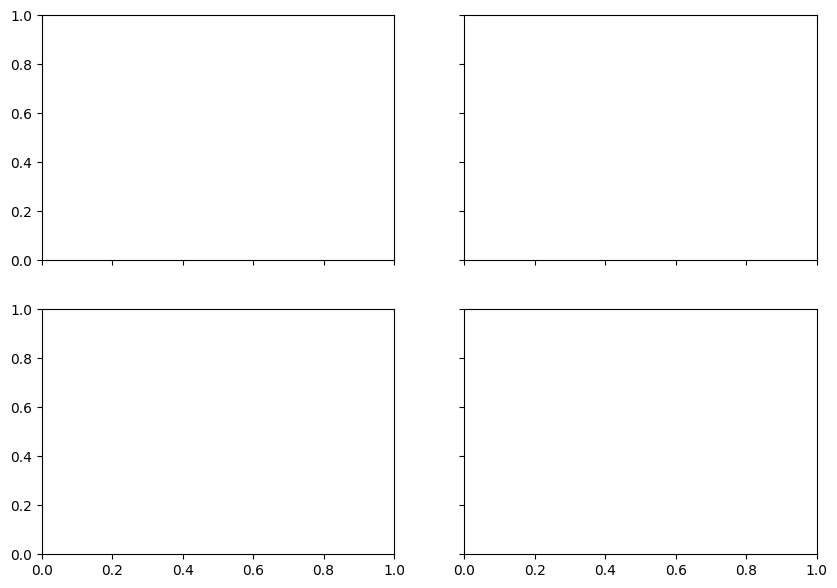

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

col = {'HEOM': '#1f77b4', 'Path integral': '#d62728'}
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)

for site, ax in enumerate(axes.flat):
    # Nur HEOM und Path integral plotten
    for name in ('HEOM', 'Path integral'):
        K = res[name]['K']
        ax.plot(t_fs[K - 1:], out_B[name][0][:, site], color=col[name], lw=2.0)
        ax.plot(t_fs, res[name]['pops'][:, site], color='k', ls='--', lw=1.1)
        
    ax.set_title(f'Site {site + 1}', fontsize=11)
    ax.set_xlim(0, t_fs[-1])
    ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.25)
    if site >= 2: 
        ax.set_xlabel('time / fs')
    if site % 2 == 0: 
        ax.set_ylabel('population')

# Legende für HEOM und Path integral + Referenz
handles = [Line2D([], [], color=col[n], lw=2.0, label=f'{n} — single circuit') 
           for n in ('Path integral', 'HEOM')]
handles.append(Line2D([], [], color='k', ls='--', lw=1.1, label='step-by-step reference'))

# ncol auf 3 reduziert, da Lindblad fehlt
fig.legend(handles=handles, loc='upper center', ncol=3, frameon=False, fontsize=9,
           bbox_to_anchor=(0.5, 0.965))
fig.suptitle('HEOM & Path integral: Whole trajectory from ONE circuit', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.93])

fig.savefig(f'pictures/single_grid_HEOM_PI_N{N}.png', dpi=200)
plt.show()
print(f'wrote pictures/single_grid_HEOM_PI_N{N}.png')